# One-to-One Classification: Cross-Combination Result Comparison

Compares model performance across every one-to-one label-pair classification trained via
`03_main_training.py --n_splits 5` on `config.LAB_1TO1_EXP_FOLDER` (`LAB_OneToOne`) --
20 combinations total: 2 strategies (`1_area`, `2_range`) x C(5,2)=10 label pairs each
(`Pf`/`Pk`/`Pm`/`Po`/`Pv`), one subfolder per combo (see `01b_lab_curve_preprocessing.py`'s
`--one_to_one` mode).

Three questions this notebook answers:
1. **Consistency across one-to-one classifications** -- for each model, how stable is its
   accuracy across all 10 (or 20) label-pair combos, not just its average?
2. **Which model is significantly better (and consistent)** -- a real significance test
   (Friedman + pairwise Wilcoxon, Holm-corrected), reusing `08_statistical_comparison.py`'s
   existing statistical engine rather than re-implementing it.
3. **`1_area` vs `2_range` consistency for the same target pairs** -- both strategies
   classify the exact same 10 label pairs; do they agree on which pairs/models work well?

Each combo's `classification_performances_10fold.joblib` has REAL 5-fold CV (unlike a
single LOFO fold), so `accuracy_std` here is genuine fold-to-fold variability, not always 0.

In [3]:
import os

try:
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        os.chdir(os.path.dirname(notebook_path))
except Exception as e:
    print(f"Could not change directory: {e}")

print("Current Working Directory:", os.getcwd())
%load_ext autoreload
%autoreload 2
%matplotlib inline

Current Working Directory: /vol/bitbucket/gk225/POC_DDM/gk_code/main
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import re
import importlib.util
from itertools import combinations
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import patheffects
%matplotlib inline
import config

def _load_digit_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

prep01b = _load_digit_module("prep01b", "01b_lab_curve_preprocessing.py")
stat08 = _load_digit_module("stat08", "08_statistical_comparison.py")


[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



## 1. Configuration

Combos discovered the same way `01b_lab_curve_preprocessing.py --one_to_one` itself does
(`discover_one_to_one_combos`), so this notebook always matches whatever combinations
actually exist on disk -- no hardcoded label list to fall out of sync.

In [35]:
LAB_1TO1_FOLDER = Path(config.LAB_1TO1_EXP_FOLDER)
STRATEGIES = sorted(prep01b.FILE_MAPPING_ONE_TO_ONE.keys())

COMBOS = prep01b.discover_one_to_one_combos(str(LAB_1TO1_FOLDER))
print(f"Found {len(COMBOS)} combos across {len(STRATEGIES)} strategies:")
for strategy, label1, label2, combo_name in COMBOS:
    print(f"  {combo_name}")

# Models actually trained for this dataset: LAB curves have no spatial metadata, so
# cnn_gru_dual_cosine_recon/cnn_gru_dual_attn_recon (model_utils.evaluate_outlier_filters)
# are skipped automatically -- everything else 03_main_training.py's default `models`
# list trains is present.
MODELS = ["knn", "cnn", "gru", "transformer", "cnn_lf", "gru_lf", "trans_lf", "cnn_gru_dual", "cnn_trans_dual"] #, "cnn_gru_gate", "cnn_gru_hadamard", "cnn_gru_crossattn", "cnn_gru_film", "cnn_trans_gate", "cnn_trans_hadamard", "cnn_trans_crossattn", "cnn_trans_film"]
MODEL_LABEL_MAP = config.MODEL_PRINT_MAP

MODEL_FIXED_COLORS = {
    "cnn": config.MODEL_COLORS["CNN"],
    "gru": config.MODEL_COLORS["GRU"],
    "transformer": config.MODEL_COLORS["Transformer"],
}
MODEL_COLOR_MAP = config.get_palette(MODELS, MODEL_FIXED_COLORS)

STRATEGY_COLOR_MAP = config.get_palette(STRATEGIES)
STRATEGY_LABEL_MAP = {"1_area": "Area Strategy", "2_range": "Range Strategy"}

N_SPLITS = 5

Found 20 combos across 2 strategies:
  1_area__Pf_vs_Pk
  1_area__Pf_vs_Pm
  1_area__Pf_vs_Po
  1_area__Pf_vs_Pv
  1_area__Pk_vs_Pm
  1_area__Pk_vs_Po
  1_area__Pk_vs_Pv
  1_area__Pm_vs_Po
  1_area__Pm_vs_Pv
  1_area__Po_vs_Pv
  2_range__Pf_vs_Pk
  2_range__Pf_vs_Pm
  2_range__Pf_vs_Po
  2_range__Pf_vs_Pv
  2_range__Pk_vs_Pm
  2_range__Pk_vs_Po
  2_range__Pk_vs_Pv
  2_range__Pm_vs_Po
  2_range__Pm_vs_Pv
  2_range__Po_vs_Pv


## 2. Load results into a tidy long-format DataFrame

One row per (combo, model) -- `accuracy_mean`/`accuracy_std` are computed across the 5
real CV folds in each combo's `classification_performances_10fold.joblib`.

In [ ]:
def per_fold_accuracies(res_entry, model_key):
    pred_key, _, _ = config.MODEL_KEY_MAP[model_key]
    if pred_key not in res_entry or not res_entry[pred_key]:
        return None
    y_trues, y_preds = res_entry["y_trues_"], res_entry[pred_key]
    return [float((np.asarray(yp) == np.asarray(yt)).mean()) for yt, yp in zip(y_trues, y_preds)]


def load_one_to_one_results():
    rows = []
    for strategy, label1, label2, combo_name in COMBOS:
        results_path = LAB_1TO1_FOLDER / combo_name / config.TRAINING_10FOLD_RESULT_PATH
        if not results_path.exists():
            print(f"[WARN] no 10-fold results for {combo_name}")
            continue
        all_results = joblib.load(results_path)
        if "Ori Curves" not in all_results:
            print(f"[WARN] no 'Ori Curves' (raw) results for {combo_name}")
            continue
        res_entry = all_results["Ori Curves"].get("Native", {}).get(None)
        if res_entry is None:
            print(f"[WARN] no Native/baseline results for {combo_name}")
            continue
        for model in MODELS:
            accs = per_fold_accuracies(res_entry, model)
            if accs is None:
                continue
            rows.append({
                "combo": combo_name, "strategy": strategy, "pair": f"{label1}_vs_{label2}",
                "model": model, "accuracy_mean": float(np.mean(accs)) * 100,
                "accuracy_std": float(np.std(accs)) * 100, "n_folds": len(accs),
            })
    return pd.DataFrame(rows)



results_df = load_one_to_one_results()
PAIRS = sorted(results_df["pair"].unique())
print(f"\nLoaded {len(results_df)} rows. Pairs: {PAIRS}")
results_df.head()


Loaded 180 rows. Pairs: ['Pf_vs_Pk', 'Pf_vs_Pm', 'Pf_vs_Po', 'Pf_vs_Pv', 'Pk_vs_Pm', 'Pk_vs_Po', 'Pk_vs_Pv', 'Pm_vs_Po', 'Pm_vs_Pv', 'Po_vs_Pv']


,combo,strategy,pair,model,accuracy_mean,accuracy_std,n_folds
0,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,knn,94.695431,0.668626,5
1,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,cnn,99.898477,0.050761,5
2,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,gru,99.974619,0.050761,5
3,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,transformer,99.873096,0.080261,5
4,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,cnn_lf,99.949239,0.062170,5


In [ ]:
# results_df.to_csv("/vol/bitbucket/gk225/one_to_one_results.csv", index=False)

## 3. Data completeness check

Every combo should have all 9 models; this flags anything missing (e.g. a combo whose
`03` run hasn't finished yet).

In [83]:
all_combo_names = [c[3] for c in COMBOS]
loaded_combos = set(results_df["combo"].unique())
fully_missing = [c for c in all_combo_names if c not in loaded_combos]
if fully_missing:
    print(f"{len(fully_missing)} of {len(all_combo_names)} combos have no results file at all yet:")
    for c in fully_missing:
        print(f"  {c}")

coverage = results_df.pivot_table(index="combo", columns="model", values="accuracy_mean", aggfunc="count")
coverage = coverage.reindex(columns=MODELS).fillna(0).astype(int)
partial = coverage[(coverage == 0).any(axis=1)]
if partial.empty:
    print(f"All {len(loaded_combos)} loaded combos have all {len(MODELS)} models present.")
else:
    print("Loaded combos with missing models (0 = missing):")
    display(partial)


All 20 loaded combos have all 9 models present.


## 4. Goal 1: model consistency across one-to-one classifications

For each model: mean accuracy across all combos (bar) and the spread across combos
(error bar + boxplot) -- a model that's high on average but wildly inconsistent across
label pairs is a different finding than one that's reliably mid-range everywhere.

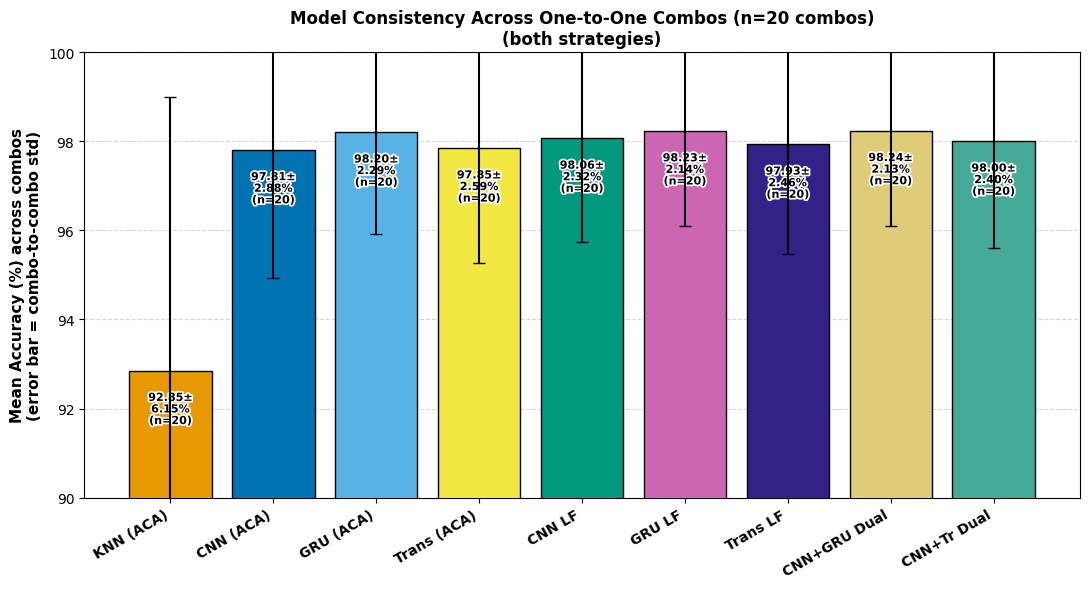

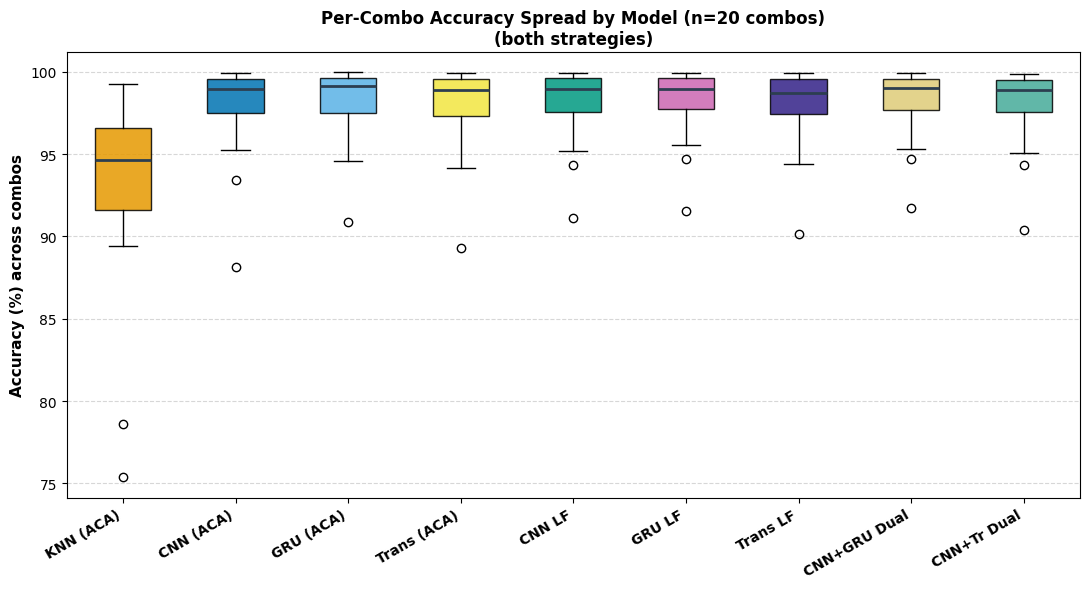

In [99]:
_TEXT_OUTLINE = [patheffects.withStroke(linewidth=2.5, foreground="white")]

def plot_model_consistency(df, strategy=None, title_suffix=""):
    sub = df if strategy is None else df[df.strategy == strategy]
    n_combos = sub["combo"].nunique()
    agg = sub.groupby("model")["accuracy_mean"].agg(["mean", "std", "count"]).reindex(MODELS)

    fig, ax = plt.subplots(figsize=(11, 6))
    colors = [MODEL_COLOR_MAP[m] for m in agg.index]
    ax.bar(range(len(agg)), agg["mean"].fillna(0), yerr=agg["std"].fillna(0), capsize=4,
           color=colors, edgecolor="black", zorder=3)
    for i, (m, s, c) in enumerate(zip(agg["mean"], agg["std"], agg["count"])):
        if not np.isnan(m):
            ax.text(i, m - 0.5, f"{m:.2f}±\n{s:.2f}%\n(n={c})", ha="center", va="top",
                     fontsize=8, fontweight="bold", path_effects=_TEXT_OUTLINE)

    valid = agg["mean"].dropna()
    ymin = max(0, (valid.min() // 10) * 10 - 0) if not valid.empty else 0
    ax.set_ylim(ymin, 100)
    ax.set_xticks(range(len(agg)))
    ax.set_xticklabels([MODEL_LABEL_MAP.get(m, m) for m in agg.index], rotation=30, ha="right", fontweight="bold")
    ax.set_ylabel("Mean Accuracy (%) across combos\n(error bar = combo-to-combo std)", fontsize=11, fontweight="bold")
    ax.set_title(f"Model Consistency Across One-to-One Combos (n={n_combos} combos){title_suffix}", fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    fig.tight_layout()
    plt.show()


def plot_model_boxplot(df, strategy=None, title_suffix=""):
    sub = df if strategy is None else df[df.strategy == strategy]
    n_combos = sub["combo"].nunique()
    data = [sub[sub.model == m]["accuracy_mean"].values for m in MODELS]

    fig, ax = plt.subplots(figsize=(11, 6))
    bp = ax.boxplot(data, patch_artist=True, tick_labels=[MODEL_LABEL_MAP.get(m, m) for m in MODELS],
                     medianprops=dict(color="#2c3e50", lw=2))
    for patch, m in zip(bp["boxes"], MODELS):
        patch.set_facecolor(MODEL_COLOR_MAP[m])
        patch.set_alpha(0.85)
    ax.set_ylabel("Accuracy (%) across combos", fontsize=11, fontweight="bold")
    ax.set_title(f"Per-Combo Accuracy Spread by Model (n={n_combos} combos){title_suffix}", fontweight="bold")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    fig.tight_layout()
    plt.show()


plot_model_consistency(results_df, title_suffix="\n(both strategies)")
plot_model_boxplot(results_df, title_suffix="\n(both strategies)")

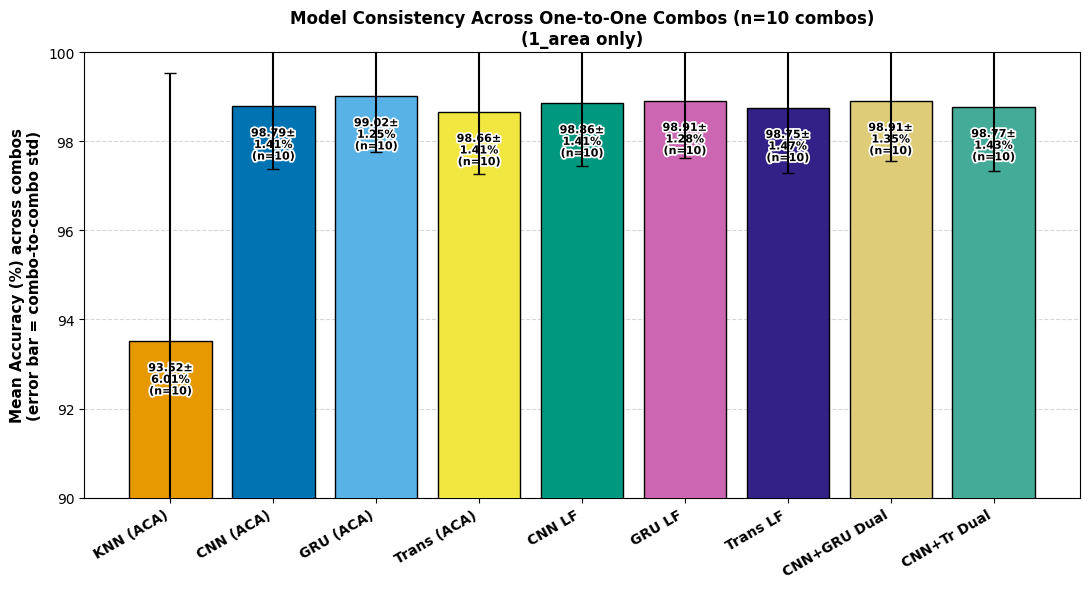

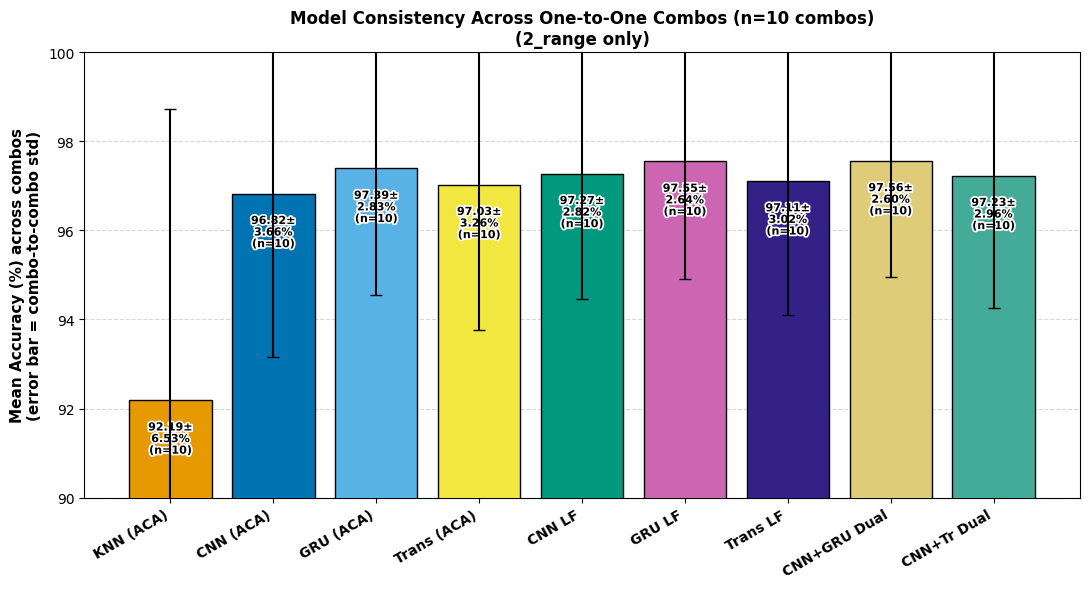

In [100]:
plot_model_consistency(results_df, strategy="1_area", title_suffix="\n(1_area only)")
plot_model_consistency(results_df, strategy="2_range", title_suffix="\n(2_range only)")

## 5. Goal 2: which model is significantly better (and consistent)?

Reuses `08_statistical_comparison.py`'s Friedman test (across all combos, treating each
combo as one repeated-measures observation) + pairwise Wilcoxon signed-rank with Holm
correction -- the same statistical engine `08` uses for its own model-comparison reports,
just fed a matrix built from the one-to-one combos instead of `08`'s own data loading.

In [69]:
def build_model_matrix(df):
    """(n_combos, n_models) matrix of accuracy_mean (0-1 scale, matching stat08's
    convention), one row per combo -- only combos with ALL models present are kept,
    since the Friedman test requires a complete matrix."""
    pivot = df.pivot_table(index="combo", columns="model", values="accuracy_mean", aggfunc="mean")
    pivot = pivot.reindex(columns=MODELS).dropna()
    return pivot.values / 100.0, list(pivot.index)


matrix, combo_order = build_model_matrix(results_df)
print(f"Matrix shape (combos x models): {matrix.shape}")

model_names = [MODEL_LABEL_MAP.get(m, m) for m in MODELS]
baseline_idx = MODELS.index("cnn_gru_dual")

stats = stat08.run_friedman_posthoc(matrix, MODELS, model_names, baseline_idx=baseline_idx)
if "error" in stats:
    print("Could not run test:", stats["error"])
else:
    print(f"Friedman chi2 = {stats['friedman_stat']:.3f}, p = {stats['friedman_p']:.4f}"
          f" -> {'SIGNIFICANT' if stats['friedman_sig'] else 'not significant'} difference among models")
    for name, rank, mean, std in sorted(zip(model_names, stats["avg_ranks"], stats["mean_values"], stats["std_values"]), key=lambda t: t[1]):
        print(f"  {name:18s} avg_rank={rank:.2f}  mean_acc={mean*100:.2f}%  std={std*100:.2f}%")

Matrix shape (combos x models): (20, 9)
Friedman chi2 = 80.858, p = 0.0000 -> SIGNIFICANT difference among models
  GRU (ACA)          avg_rank=2.90  mean_acc=98.20%  std=2.29%
  CNN+GRU Dual       avg_rank=2.95  mean_acc=98.24%  std=2.13%
  GRU LF             avg_rank=3.27  mean_acc=98.23%  std=2.14%
  CNN LF             avg_rank=4.25  mean_acc=98.06%  std=2.32%
  CNN (ACA)          avg_rank=5.10  mean_acc=97.81%  std=2.88%
  CNN+Tr Dual        avg_rank=5.38  mean_acc=98.00%  std=2.40%
  Trans LF           avg_rank=6.10  mean_acc=97.93%  std=2.46%
  Trans (ACA)        avg_rank=6.15  mean_acc=97.85%  std=2.59%
  KNN (ACA)          avg_rank=8.90  mean_acc=92.85%  std=6.15%


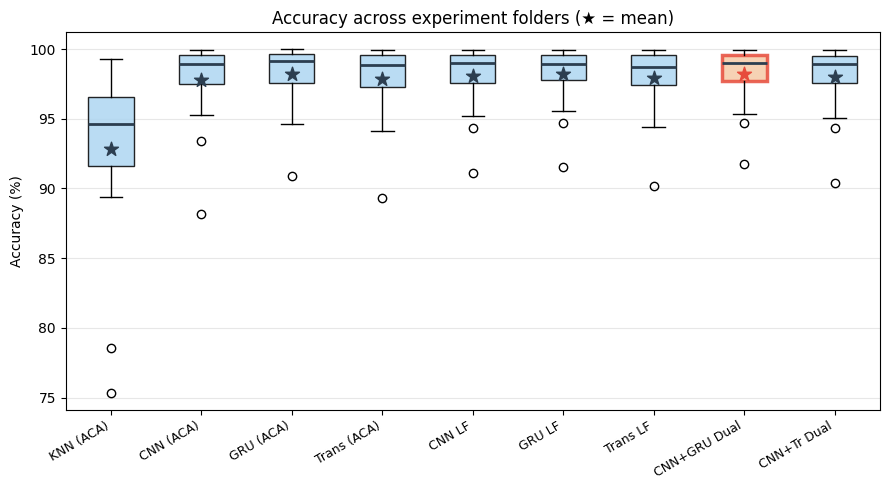

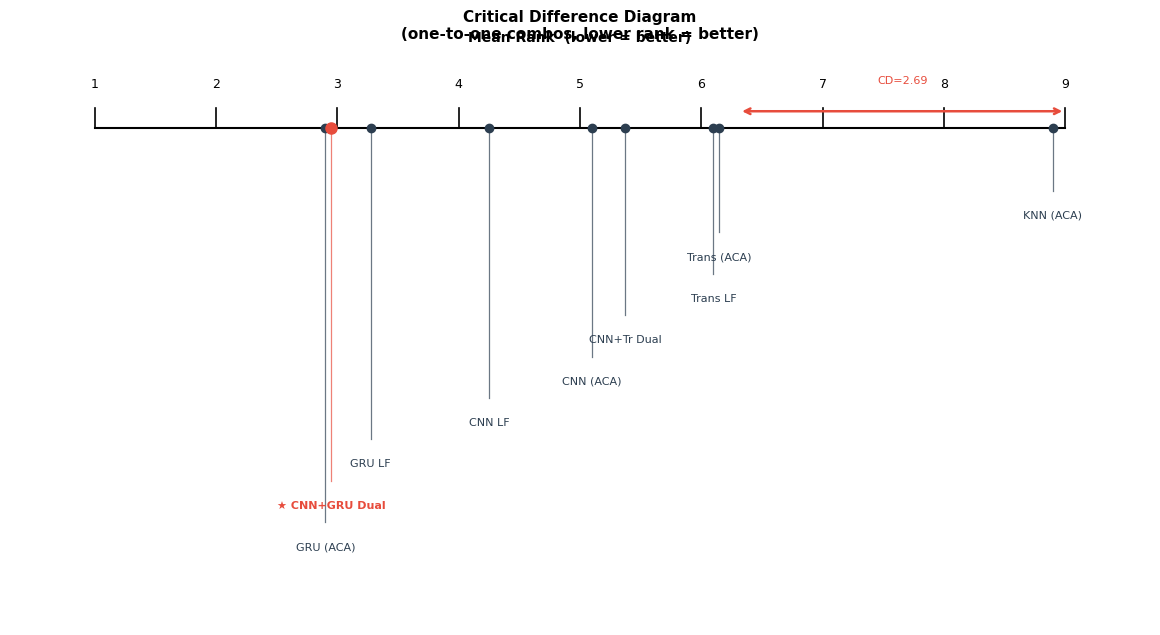

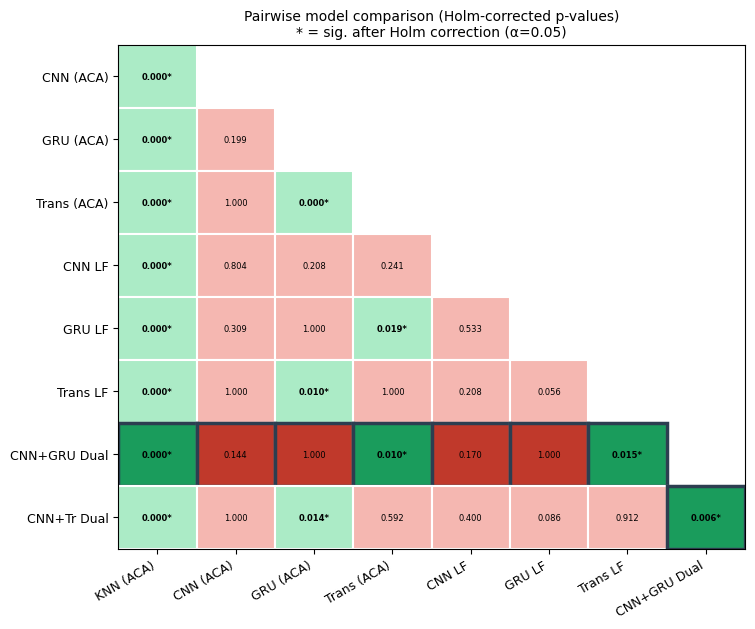

In [ ]:
%matplotlib inline
if "error" not in stats:
    stat08.plot_accuracy_boxplot(matrix, model_names, metric_name="Accuracy", baseline_idx=baseline_idx)
    stat08.plot_cd_diagram(stats["avg_ranks"], stats["cd"], model_names, baseline_idx=baseline_idx,
                          title="Critical Difference Diagram\n(one-to-one combos, lower rank = better)")
    stat08.plot_pvalue_heatmap(stats["adj_mat"], stats["rej_mat"], model_names, baseline_idx=baseline_idx,
                              title="Pairwise model comparison (Holm-corrected p-values)")

## 6. Goal 3: `1_area` vs `2_range` consistency for the same target pairs

Both strategies classify the exact same 10 label pairs -- this checks whether they agree
on which pairs/models perform well, the strategy-comparison counterpart to Section 4's
model-comparison view.

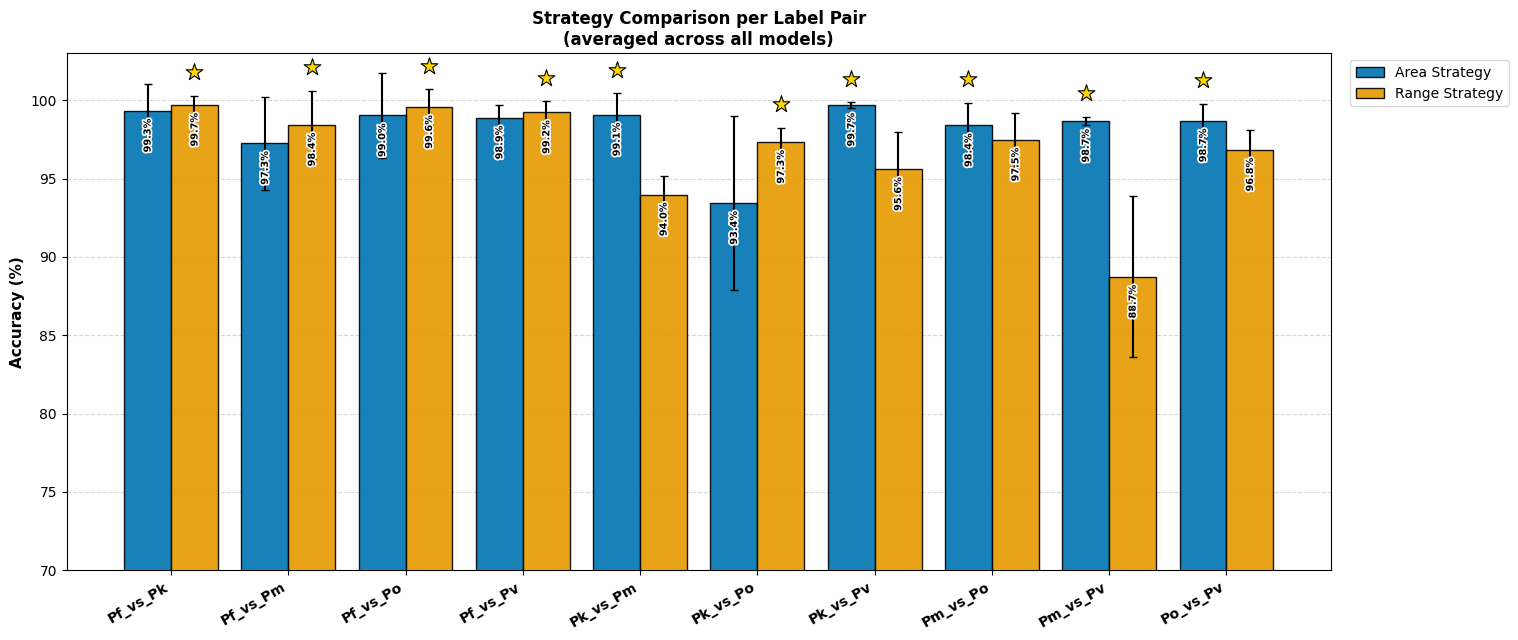

In [71]:
def grouped_bar_chart(df, x_col, x_order, hue_col, hue_order, color_map, label_map, title, figsize=None):
    n_groups = len(hue_order)
    bar_width = 0.8 / n_groups
    x = np.arange(len(x_order))
    fig, ax = plt.subplots(figsize=figsize or (max(11, len(x_order) * 1.6 + 2), 6.5))

    all_vals = []
    bar_records = []  # (group_idx, xi, key, mean, std) for every bar, used to find the per-group best
    for i, key in enumerate(hue_order):
        means, stds = [], []
        for xv in x_order:
            row = df[(df[x_col] == xv) & (df[hue_col] == key)]
            means.append(row["accuracy_mean"].mean() if not row.empty else np.nan)
            stds.append(row["accuracy_mean"].std() if len(row) > 1 else 0)
        means_arr, stds_arr = np.array(means), np.array(stds)
        all_vals.extend(means_arr[~np.isnan(means_arr)].tolist())
        offset = (i - n_groups / 2 + 0.5) * bar_width
        xi_positions = x + offset
        ax.bar(xi_positions, np.nan_to_num(means_arr, nan=0.0), width=bar_width, yerr=stds_arr,
               capsize=3, label=label_map.get(key, str(key)), color=color_map.get(key, "#ccc"),
               edgecolor="black", linewidth=1, alpha=0.9, zorder=3)
        for xi, m in zip(xi_positions, means_arr):
            if not np.isnan(m):
                ax.text(xi, m - 0.5, f"{m:.1f}%", ha="center", va="top", fontsize=7,
                         fontweight="bold", rotation=90, path_effects=_TEXT_OUTLINE, zorder=4)
        for j, (xi, m, s) in enumerate(zip(xi_positions, means_arr, stds_arr)):
            bar_records.append((j, xi, key, m, s))

    # star above the highest hue value within each x-group
    for j in range(len(x_order)):
        group_bars = [(xi, m, s) for (gj, xi, key, m, s) in bar_records if gj == j and not np.isnan(m)]
        if not group_bars:
            continue
        best_xi, best_m, best_s = max(group_bars, key=lambda t: t[1])
        ax.scatter(best_xi, best_m + best_s + 1.5, marker="*", s=160, color="gold",
                   edgecolor="black", linewidth=0.8, zorder=5)

    valid = [v for v in all_vals if not np.isnan(v)]
    ymin = max(0, (min(valid) // 10) * 10 - 10) if valid else 0
    ax.set_ylim(ymin, 103)
    ax.set_xticks(x)
    ax.set_xticklabels(x_order, rotation=30, ha="right", fontweight="bold")
    ax.set_ylabel("Accuracy (%)", fontsize=11, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=10)
    fig.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

# Averaged across all models, per pair
grouped_bar_chart(results_df, "pair", PAIRS, "strategy", STRATEGIES, STRATEGY_COLOR_MAP, STRATEGY_LABEL_MAP,
                   "Strategy Comparison per Label Pair\n(averaged across all models)")

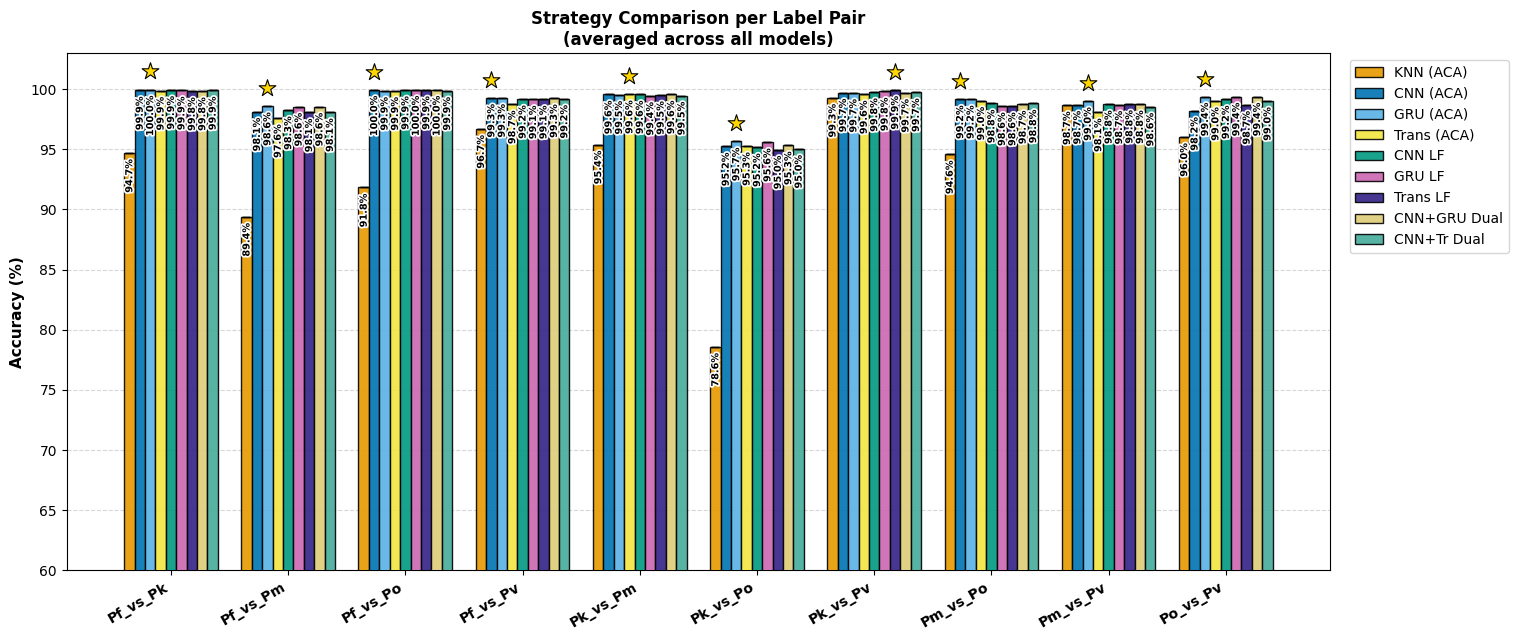

In [104]:
grouped_bar_chart(results_df[results_df.strategy == "1_area"], "pair", PAIRS, "model", MODELS, MODEL_COLOR_MAP, MODEL_LABEL_MAP,
                   "Strategy Comparison per Label Pair\n(averaged across all models)")

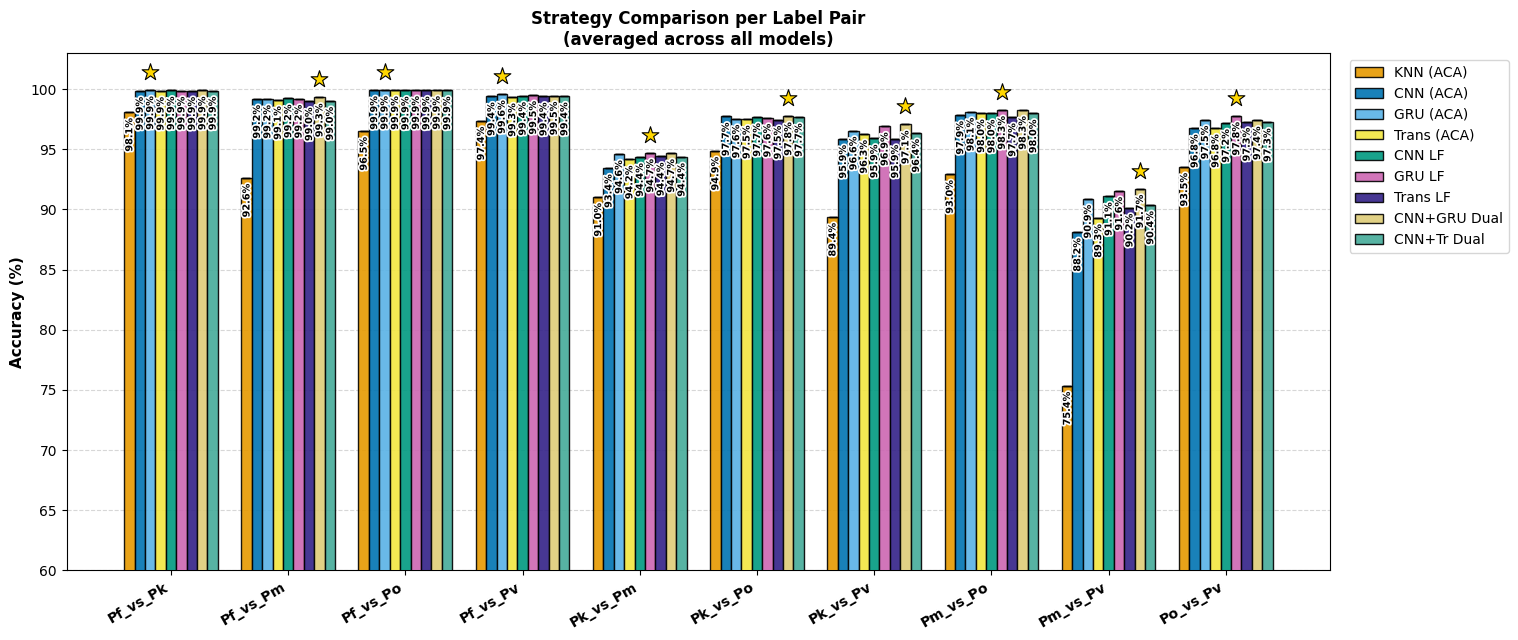

In [105]:
grouped_bar_chart(results_df[results_df.strategy == "2_range"], "pair", PAIRS, "model", MODELS, MODEL_COLOR_MAP, MODEL_LABEL_MAP,
                   "Strategy Comparison per Label Pair\n(averaged across all models)")

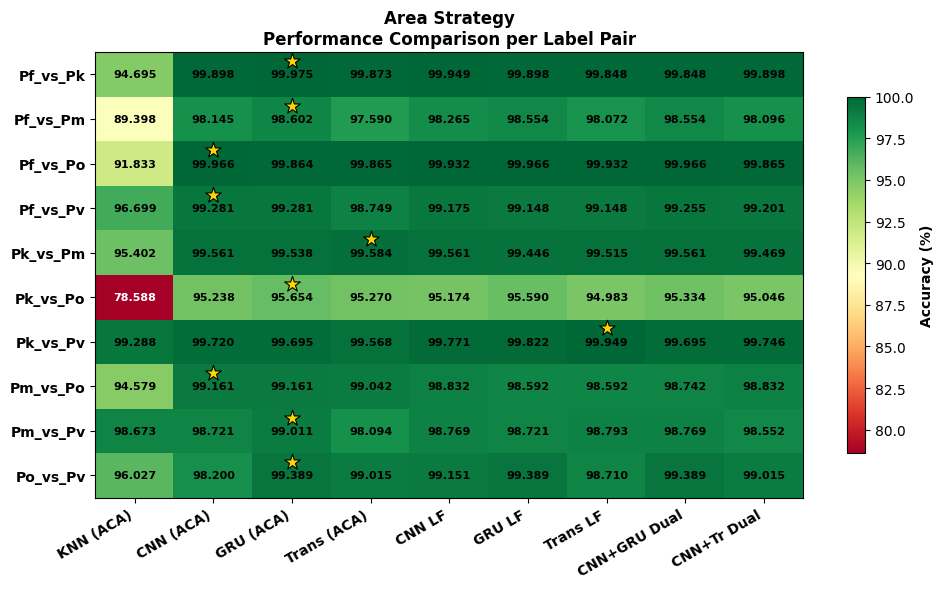

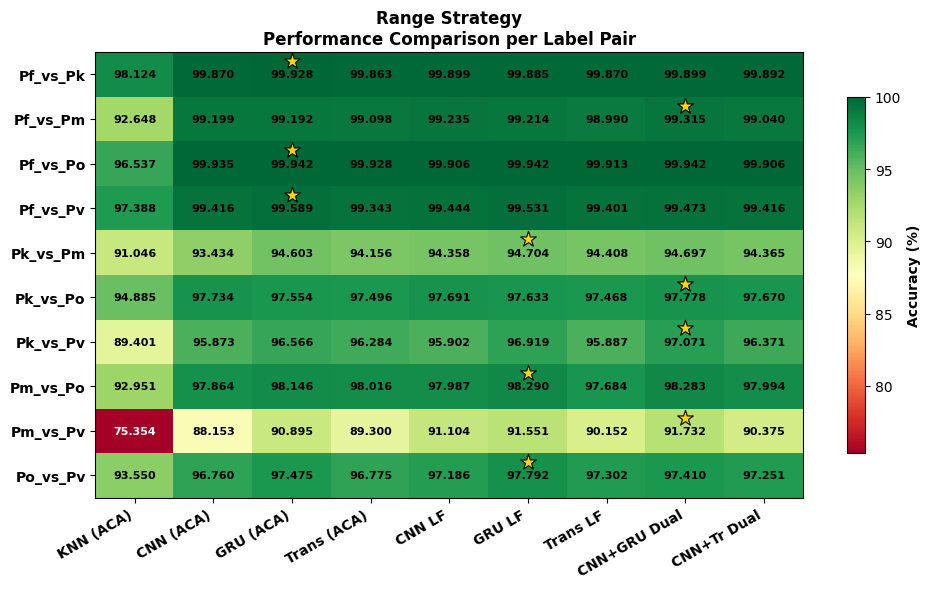

In [116]:
def plot_accuracy_heatmap(df, x_col, x_order, y_col, y_order, label_map, title, value_col="accuracy_mean",
                           cmap="RdYlGn", vmin=None, vmax=100, figsize=None):
    pivot = df.pivot_table(index=y_col, columns=x_col, values=value_col, aggfunc="mean")
    pivot = pivot.reindex(index=y_order, columns=x_order)

    fig, ax = plt.subplots(figsize=figsize or (max(10, len(x_order) * 0.9), max(5, len(y_order) * 0.6)))
    vmin = pivot.min().min() if vmin is None else vmin
    im = ax.imshow(pivot.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                text_color = "white" if val < (vmin + vmax) / 2 else "black"
                ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=8,
                        fontweight="bold", color=text_color)

    # gold star on the best-performing model for each pair (row)
    for i in range(pivot.shape[0]):
        row = pivot.values[i]
        if np.all(np.isnan(row)):
            continue
        best_j = np.nanargmax(row)
        ax.scatter(best_j, i-0.3, marker="*", s=140, color="gold", edgecolor="black",
                   linewidth=0.8, zorder=5)

    ax.set_xticks(range(len(x_order)))
    ax.set_xticklabels([label_map.get(x, x) for x in x_order], rotation=30, ha="right", fontweight="bold")
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(y_order, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label("Accuracy (%)", fontweight="bold")
    fig.tight_layout()
    plt.show()


plot_accuracy_heatmap(results_df[results_df.strategy == "1_area"], "model", MODELS, "pair", PAIRS, MODEL_LABEL_MAP,
                      "Area Strategy\nPerformance Comparison per Label Pair")

plot_accuracy_heatmap(results_df[results_df.strategy == "2_range"], "model", MODELS, "pair", PAIRS, MODEL_LABEL_MAP,
                      "Range Strategy\nPerformance Comparison per Label Pair")

In [72]:
STRATEGIES

['1_area', '2_range']

In [73]:
MODELS

['knn',
 'cnn',
 'gru',
 'transformer',
 'cnn_lf',
 'gru_lf',
 'trans_lf',
 'cnn_gru_dual',
 'cnn_trans_dual']

In [74]:
results_df

,combo,strategy,pair,model,accuracy_mean,accuracy_std,n_folds
0,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,knn,94.695431,0.668626,5
1,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,cnn,99.898477,0.050761,5
2,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,gru,99.974619,0.050761,5
3,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,transformer,99.873096,0.080261,5
4,1_area__Pf_vs_Pk,1_area,Pf_vs_Pk,cnn_lf,99.949239,0.062170,5
...,...,...,...,...,...,...,...
175,2_range__Po_vs_Pv,2_range,Po_vs_Pv,cnn_lf,97.186147,0.444763,5
176,2_range__Po_vs_Pv,2_range,Po_vs_Pv,gru_lf,97.792208,0.303888,5
177,2_range__Po_vs_Pv,2_range,Po_vs_Pv,trans_lf,97.301587,0.373790,5
178,2_range__Po_vs_Pv,2_range,Po_vs_Pv,cnn_gru_dual,97.409812,0.275118,5


In [75]:
sub = results_df[results_df.strategy == '1_area']

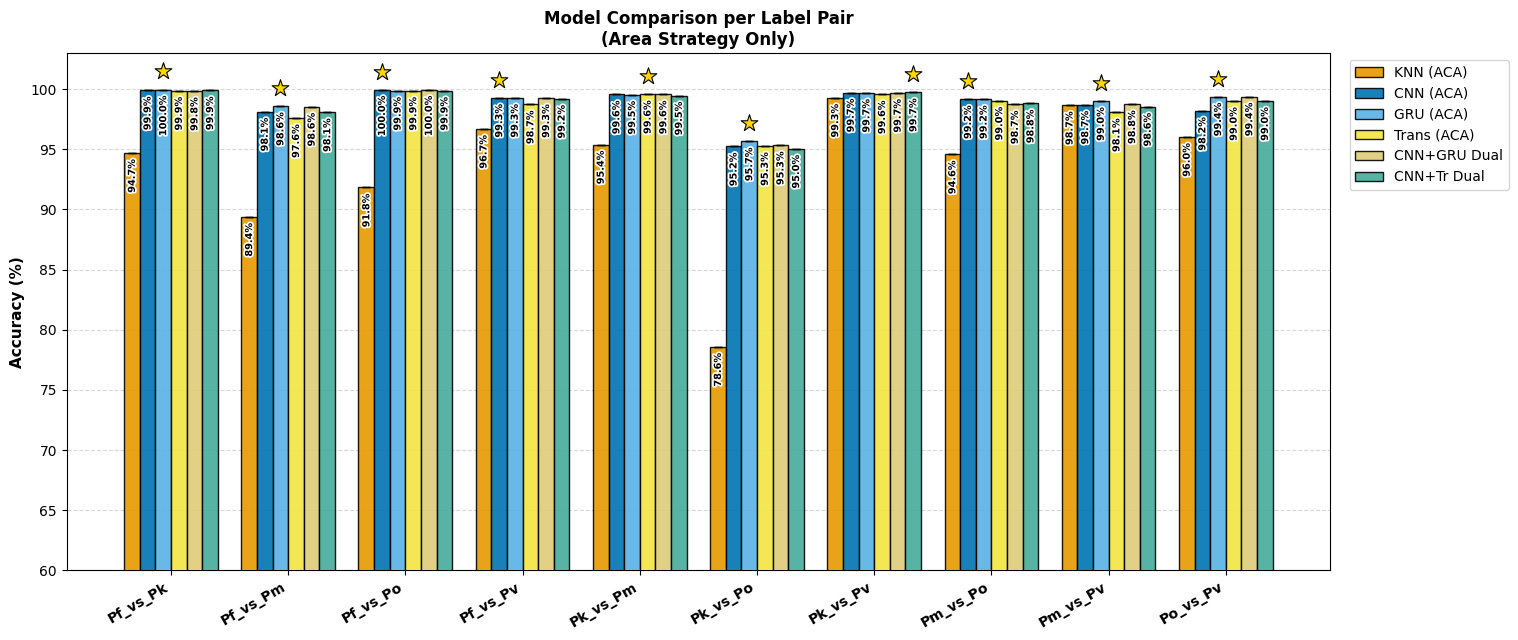

In [76]:
grouped_bar_chart(sub, "pair", PAIRS, "model", MODELS[:4]+MODELS[7:],  MODEL_COLOR_MAP, MODEL_LABEL_MAP,
                    f"Model Comparison per Label Pair\n(Area Strategy Only)")

In [77]:
MODELS

['knn',
 'cnn',
 'gru',
 'transformer',
 'cnn_lf',
 'gru_lf',
 'trans_lf',
 'cnn_gru_dual',
 'cnn_trans_dual']

In [78]:
PAIRS

['Pf_vs_Pk',
 'Pf_vs_Pm',
 'Pf_vs_Po',
 'Pf_vs_Pv',
 'Pk_vs_Pm',
 'Pk_vs_Po',
 'Pk_vs_Pv',
 'Pm_vs_Po',
 'Pm_vs_Pv',
 'Po_vs_Pv']

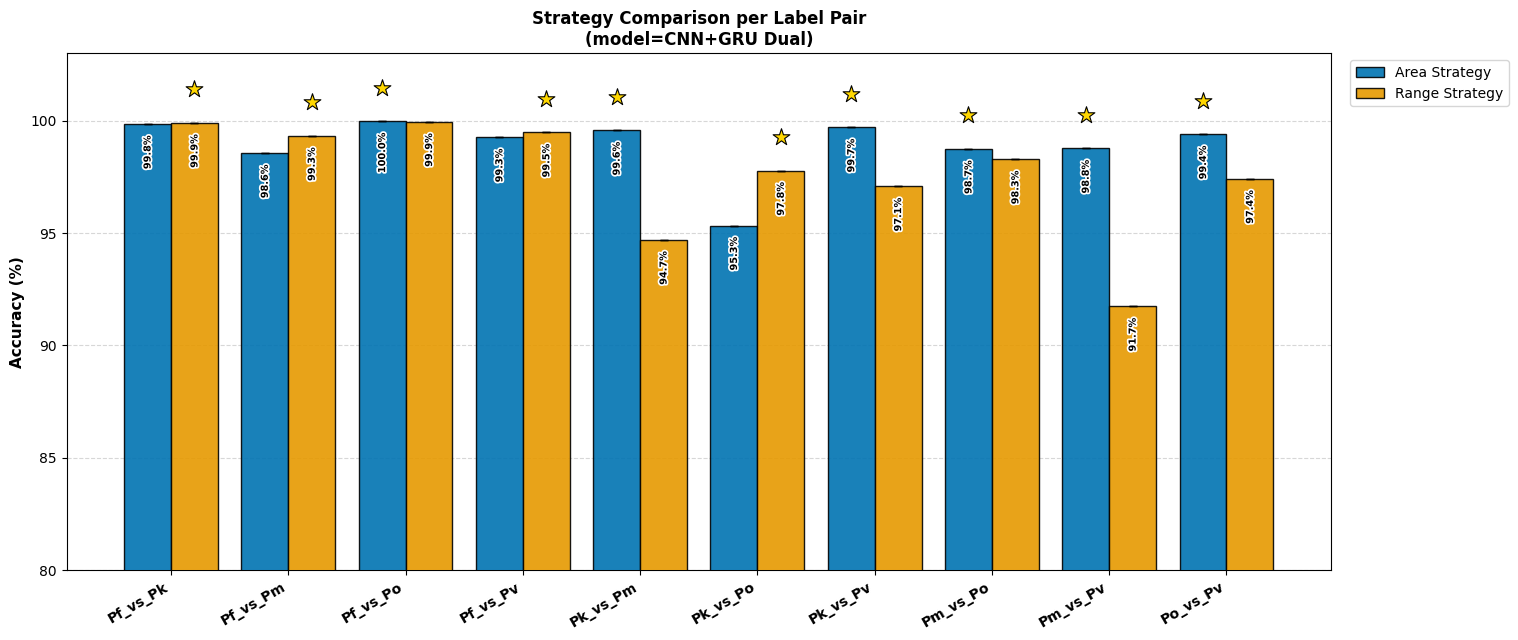

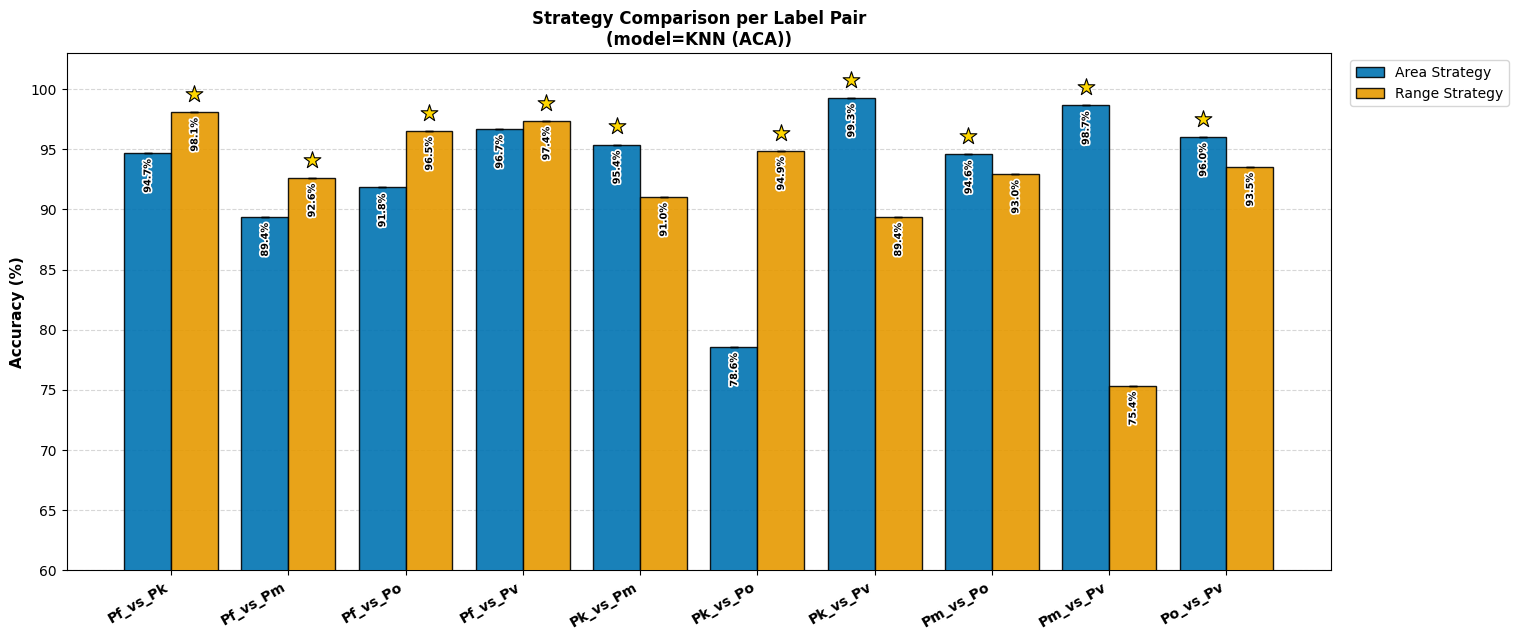

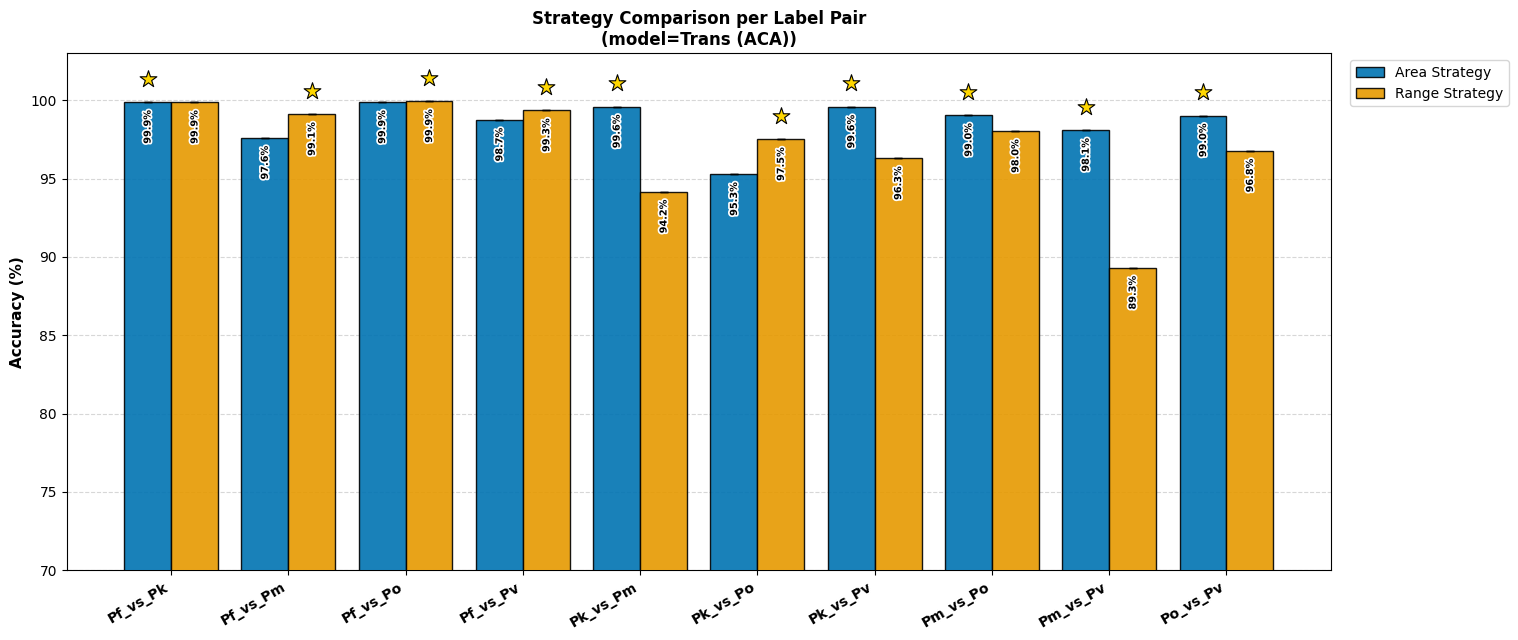

In [79]:
%matplotlib inline
# Same, for one specific model at a time
for model in ["cnn_gru_dual", "knn", "transformer"]:
    sub = results_df[results_df.model == model]
    grouped_bar_chart(sub, "pair", PAIRS, "strategy", STRATEGIES, STRATEGY_COLOR_MAP, STRATEGY_LABEL_MAP,
                       f"Strategy Comparison per Label Pair\n(model={MODEL_LABEL_MAP.get(model, model)})")

### Strategy agreement: correlation + paired significance test

If the two strategies "agree", a (pair, model) combo that scores high under `1_area`
should also score high under `2_range`. Pearson correlation across every matched
(pair, model) point gives a single consistency number; the paired Wilcoxon test (treating
each (pair, model) as one matched observation) checks whether one strategy is
systematically, significantly better than the other -- not just different on average.

Matched (pair, model) observations: 90
Pearson correlation between 1_area and 2_range accuracy: 0.139


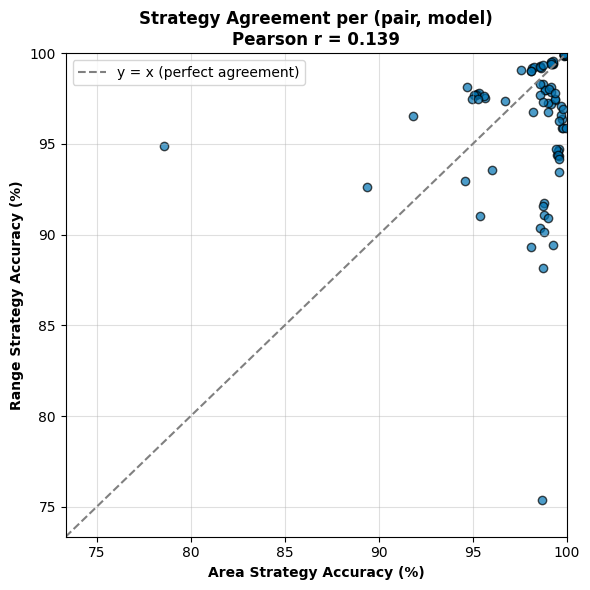


Paired Wilcoxon (1_area vs 2_range): W=1253.00, p=0.0014 -> SIGNIFICANT difference
Mean (1_area - 2_range): +1.56pp, std: 4.39pp


In [80]:
wide = results_df.pivot_table(index=["pair", "model"], columns="strategy", values="accuracy_mean")
wide = wide.dropna()
print(f"Matched (pair, model) observations: {len(wide)}")

corr = wide["1_area"].corr(wide["2_range"])
print(f"Pearson correlation between 1_area and 2_range accuracy: {corr:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(wide["1_area"], wide["2_range"], alpha=0.7, edgecolor="black")
lims = [min(wide.min()) - 2, 100]
ax.plot(lims, lims, "--", color="gray", label="y = x (perfect agreement)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Area Strategy Accuracy (%)", fontweight="bold")
ax.set_ylabel("Range Strategy Accuracy (%)", fontweight="bold")
ax.set_title(f"Strategy Agreement per (pair, model)\nPearson r = {corr:.3f}", fontweight="bold")
ax.legend()
ax.grid(alpha=0.4)
fig.tight_layout()
plt.show()

from scipy.stats import wilcoxon
w_stat, w_p = wilcoxon(wide["1_area"], wide["2_range"], alternative="two-sided", zero_method="pratt")
diff = wide["1_area"] - wide["2_range"]
print(f"\nPaired Wilcoxon (1_area vs 2_range): W={w_stat:.2f}, p={w_p:.4f}"
      f" -> {'SIGNIFICANT' if w_p < 0.05 else 'not significant'} difference")
print(f"Mean (1_area - 2_range): {diff.mean():+.2f}pp, std: {diff.std():.2f}pp")

## 7. Goal 4: `ori_curve` vs `ori_curve_norm` -- does per-curve normalisation help, and which model is consistent enough to use?

Loads both curve variants trained per combo (`ori_curve` = raw, `ori_curve_norm` = each
curve independently min-max scaled to [0,1] via `01b`'s `--normalize_curves`), then
compares accuracy and combo-to-combo consistency side by side.

In [81]:
CURVE_TYPES = ["ori", "ori_norm"]
CURVE_LABEL_MAP = {"ori": "Raw Curve", "ori_norm": "Normalised Curve"}
CURVE_COLOR_MAP = config.get_palette(CURVE_TYPES)
DATASET_TO_CURVE_TYPE = {"Ori Curves": "ori", "Ori Curves Norm": "ori_norm"}

def load_one_to_one_results_by_curve_type():
    rows = []
    for strategy, label1, label2, combo_name in COMBOS:
        results_path = LAB_1TO1_FOLDER / combo_name / config.TRAINING_10FOLD_RESULT_PATH
        if not results_path.exists():
            continue
        all_results = joblib.load(results_path)
        for dataset_name, curve_type in DATASET_TO_CURVE_TYPE.items():
            if dataset_name not in all_results:
                continue
            res_entry = all_results[dataset_name].get("Native", {}).get(None)
            if res_entry is None:
                continue
            for model in MODELS:
                accs = per_fold_accuracies(res_entry, model)
                if accs is None:
                    continue
                rows.append({
                    "combo": combo_name, "strategy": strategy, "pair": f"{label1}_vs_{label2}",
                    "model": model, "curve_type": curve_type,
                    "accuracy_mean": float(np.mean(accs)) * 100,
                    "accuracy_std": float(np.std(accs)) * 100, "n_folds": len(accs),
                })
    return pd.DataFrame(rows)


curve_df = load_one_to_one_results_by_curve_type()
print(f"Loaded {len(curve_df)} rows ({curve_df['curve_type'].value_counts().to_dict()})")

# completeness check, per (combo, curve_type) -- ori_norm trains independently of ori,
# so its own models can fail/be missing even when ori's are complete
coverage = curve_df.pivot_table(index=["combo", "curve_type"], columns="model", values="accuracy_mean", aggfunc="count")
coverage = coverage.reindex(columns=MODELS).fillna(0).astype(int)
incomplete = coverage[(coverage == 0).any(axis=1)]
if incomplete.empty:
    print("All (combo, curve_type) pairs have every model present.")
else:
    print(f"{len(incomplete)} (combo, curve_type) row(s) missing at least one model:")
    display(incomplete.loc[:, (incomplete == 0).any(axis=0)])

Loaded 360 rows ({'ori': 180, 'ori_norm': 180})
All (combo, curve_type) pairs have every model present.


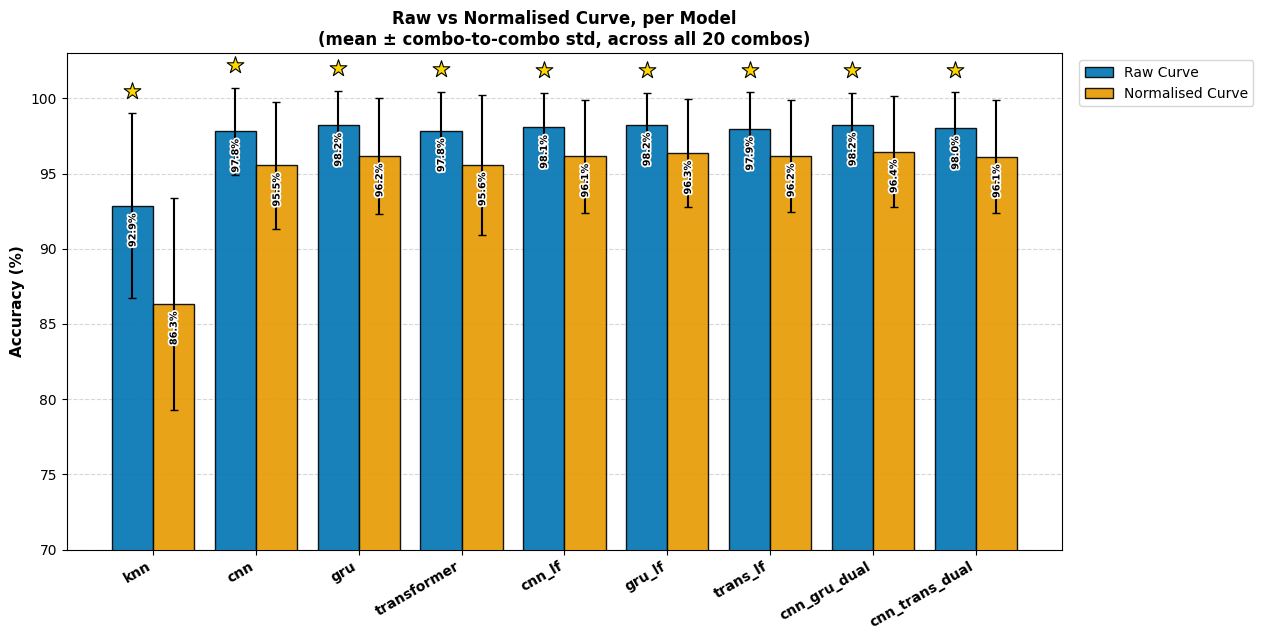

In [53]:
grouped_bar_chart(curve_df, "model", MODELS, "curve_type", CURVE_TYPES, CURVE_COLOR_MAP, CURVE_LABEL_MAP,
                   "Raw vs Normalised Curve, per Model\n(mean ± combo-to-combo std, across all 20 combos)",
                   figsize=(15, 6.5))

### Raw vs normalised agreement: correlation + paired significance test

Mirrors Section 6's strategy-agreement test, but for curve type instead of strategy.

Matched (combo, model) observations: 180
Pearson correlation between ori and ori_norm accuracy: 0.766


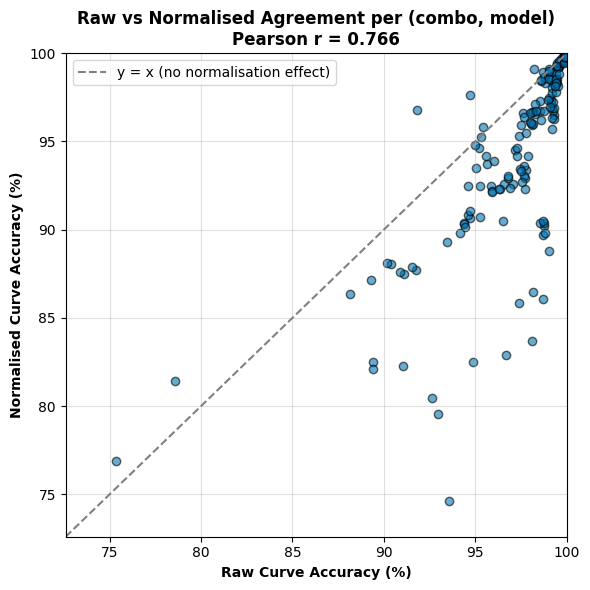


Paired Wilcoxon (ori vs ori_norm): W=699.00, p=0.0000 -> SIGNIFICANT difference
Mean (ori - ori_norm): +2.48pp, std: 3.45pp


In [54]:
wide_curve = curve_df.pivot_table(index=["combo", "model"], columns="curve_type", values="accuracy_mean").dropna()
print(f"Matched (combo, model) observations: {len(wide_curve)}")

corr = wide_curve["ori"].corr(wide_curve["ori_norm"])
print(f"Pearson correlation between ori and ori_norm accuracy: {corr:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(wide_curve["ori"], wide_curve["ori_norm"], alpha=0.6, edgecolor="black")
lims = [min(wide_curve.min()) - 2, 100]
ax.plot(lims, lims, "--", color="gray", label="y = x (no normalisation effect)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Raw Curve Accuracy (%)", fontweight="bold")
ax.set_ylabel("Normalised Curve Accuracy (%)", fontweight="bold")
ax.set_title(f"Raw vs Normalised Agreement per (combo, model)\nPearson r = {corr:.3f}", fontweight="bold")
ax.legend()
ax.grid(alpha=0.4)
fig.tight_layout()
plt.show()

from scipy.stats import wilcoxon
w_stat, w_p = wilcoxon(wide_curve["ori"], wide_curve["ori_norm"], alternative="two-sided", zero_method="pratt")
diff = wide_curve["ori"] - wide_curve["ori_norm"]
print(f"\nPaired Wilcoxon (ori vs ori_norm): W={w_stat:.2f}, p={w_p:.4f}"
      f" -> {'SIGNIFICANT' if w_p < 0.05 else 'not significant'} difference")
print(f"Mean (ori - ori_norm): {diff.mean():+.2f}pp, std: {diff.std():.2f}pp")

### Which model is consistent enough to use?

A model is "consistent enough" here if it: (a) has complete results across all 20 combos
for *both* curve types, (b) keeps a low combo-to-combo std under both raw and normalised
curves, and (c) doesn't degrade sharply when curves are normalised.

In [55]:
pivot_mean = curve_df.pivot_table(index="model", columns="curve_type", values="accuracy_mean", aggfunc="mean")
pivot_std = curve_df.pivot_table(index="model", columns="curve_type", values="accuracy_mean", aggfunc="std")
pivot_count = curve_df.pivot_table(index="model", columns="curve_type", values="accuracy_mean", aggfunc="count")

full_coverage = pivot_count[(pivot_count["ori"] == len(COMBOS)) & (pivot_count["ori_norm"] == len(COMBOS))].index
excluded = [m for m in MODELS if m not in full_coverage]

rank_df = pd.DataFrame({
    "mean_ori": pivot_mean.loc[full_coverage, "ori"], "std_ori": pivot_std.loc[full_coverage, "ori"],
    "mean_norm": pivot_mean.loc[full_coverage, "ori_norm"], "std_norm": pivot_std.loc[full_coverage, "ori_norm"],
})
rank_df["mean_combined"] = (rank_df["mean_ori"] + rank_df["mean_norm"]) / 2
rank_df["worst_std"] = rank_df[["std_ori", "std_norm"]].max(axis=1)
rank_df["drop_ori_to_norm"] = rank_df["mean_ori"] - rank_df["mean_norm"]
rank_df = rank_df.sort_values(["worst_std", "mean_combined"], ascending=[True, False])

print(f"Excluded {len(excluded)} model(s) with incomplete coverage in at least one curve type "
      f"(missing for some combos -- itself a sign of instability): {[MODEL_LABEL_MAP.get(m, m) for m in excluded]}\n")
display(rank_df.round(2))

best, runner_up = rank_df.index[0], rank_df.index[1]
print(f"\n[CONCLUSION] '{MODEL_LABEL_MAP.get(best, best)}' is the most consistent model to use: "
      f"{rank_df.loc[best, 'mean_combined']:.2f}% mean accuracy across raw+normalised curves, "
      f"with the lowest worst-case combo-to-combo std ({rank_df.loc[best, 'worst_std']:.2f}pp) among "
      f"models with complete results on both curve types.")
print(f"'{MODEL_LABEL_MAP.get(runner_up, runner_up)}' is a close runner-up "
      f"({rank_df.loc[runner_up, 'mean_combined']:.2f}% mean, {rank_df.loc[runner_up, 'worst_std']:.2f}pp worst std).")

max_excluded_std = curve_df[curve_df.model.isin(excluded)].groupby("model")["accuracy_mean"].std().max()
print(f"\nGated dual-branch fusion variants and KNN are NOT recommended: incomplete coverage and/or much "
      f"higher combo-to-combo std (up to ~{max_excluded_std:.0f}pp), sensitive to input scale rather than "
      f"robustly consistent.")

Excluded 0 model(s) with incomplete coverage in at least one curve type (missing for some combos -- itself a sign of instability): []



,mean_ori,std_ori,mean_norm,std_norm,mean_combined,worst_std,drop_ori_to_norm
model,,,,,,,
gru_lf,98.23,2.14,96.35,3.61,97.29,3.61,1.88
cnn_gru_dual,98.24,2.13,96.44,3.69,97.34,3.69,1.80
trans_lf,97.93,2.46,96.17,3.72,97.05,3.72,1.76
cnn_trans_dual,98.00,2.40,96.11,3.74,97.06,3.74,1.89
cnn_lf,98.06,2.32,96.15,3.75,97.11,3.75,1.92
gru,98.20,2.29,96.17,3.87,97.18,3.87,2.04
cnn,97.81,2.88,95.54,4.24,96.67,4.24,2.26
transformer,97.85,2.59,95.57,4.63,96.71,4.63,2.27
knn,92.85,6.15,86.35,7.05,89.60,7.05,6.51



[CONCLUSION] 'GRU LF' is the most consistent model to use: 97.29% mean accuracy across raw+normalised curves, with the lowest worst-case combo-to-combo std (3.61pp) among models with complete results on both curve types.
'CNN+GRU Dual' is a close runner-up (97.34% mean, 3.69pp worst std).

Gated dual-branch fusion variants and KNN are NOT recommended: incomplete coverage and/or much higher combo-to-combo std (up to ~nanpp), sensitive to input scale rather than robustly consistent.


In [56]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import config

def plot_curve_for_training_by_target(exp_folder, folder_index):
    """Visualizes curve_for_training.joblib's curves as a line chart: x=timestamp/cycle,
    hue=target, line=mean curve per target group (shaded band=+/-1 std).
    """
    folder_names = sorted([
        name for name in os.listdir(exp_folder)
        if os.path.isdir(os.path.join(exp_folder, name)) and name not in config.EXCLUDED_FOLDERS
    ])
    if folder_index >= len(folder_names):
        raise IndexError(f"folder_index {folder_index} out of bounds for {len(folder_names)} folders: {folder_names}")
    folder_name = folder_names[folder_index]
    data_path = os.path.join(exp_folder, folder_name, config.TRAINING_DATA_PATH)
    data = joblib.load(data_path)

    curves = data["curves"]["ori_curves"]
    timestamps = data["timestamps"]
    well_labels = np.asarray(data["well_labels"])

    fig, ax = plt.subplots(figsize=(12, 7))
    for target in sorted(set(well_labels)):
        mask = well_labels == target
        mean_curve = curves[mask].mean(axis=0)
        std_curve = curves[mask].std(axis=0)
        line, = ax.plot(timestamps, mean_curve, label=f"{target} (n={mask.sum()})", lw=2)
        ax.fill_between(timestamps, mean_curve - std_curve, mean_curve + std_curve,
                         color=line.get_color(), alpha=0.05)

    ax.set_xlabel("Timestamp / Cycle", fontsize=11, fontweight="bold")
    ax.set_ylabel("Signal", fontsize=11, fontweight="bold")
    ax.set_title(f"{folder_name}: Mean Curve ± Std by Target", fontsize=13, fontweight="bold")
    ax.legend(title="Target", fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

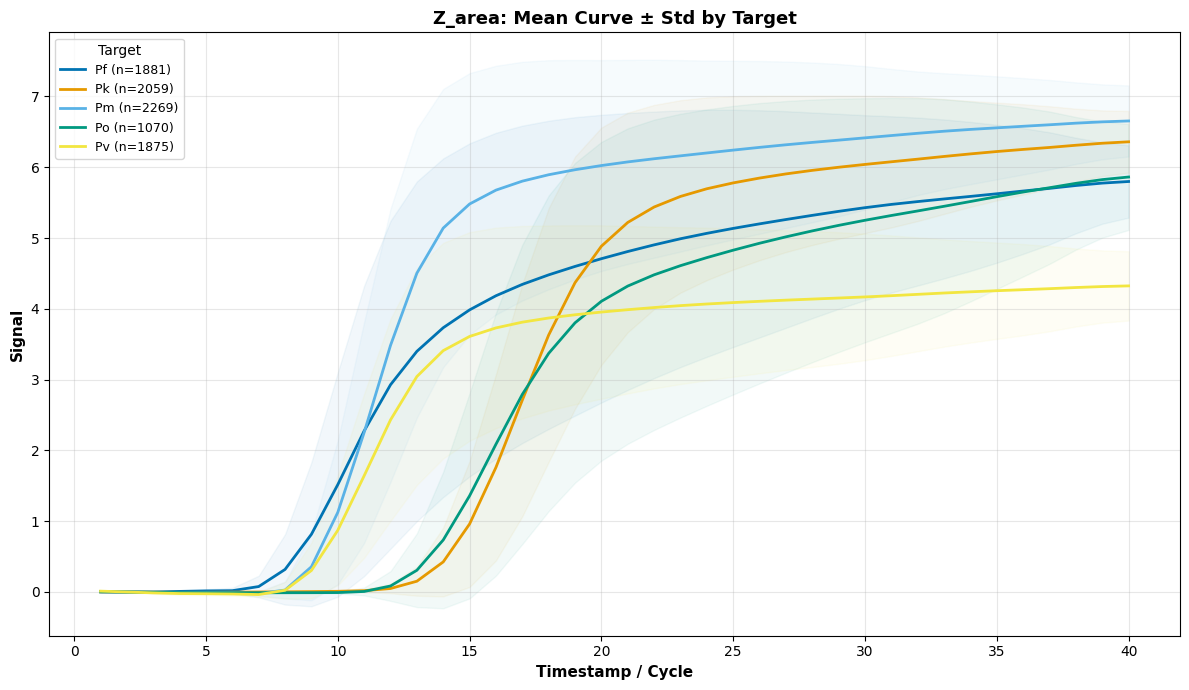

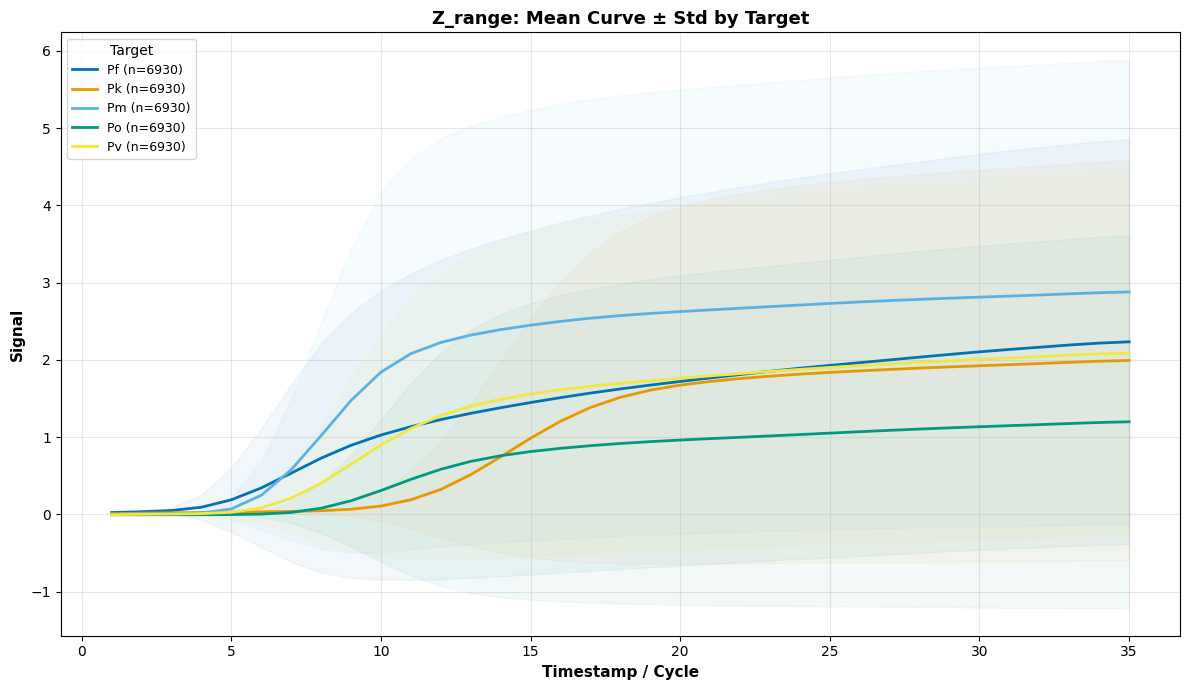

In [57]:
plot_curve_for_training_by_target(config.LAB_EXP_FOLDER, folder_index=3)
plot_curve_for_training_by_target(config.LAB_EXP_FOLDER, folder_index=4)

In [58]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib.util
import config

# Reuse 01b_lab_curve_preprocessing.py's FILE_MAPPING / FILE_TARGET / _read_table / get_numeric_sort_key
spec = importlib.util.spec_from_file_location(
    "lab01b", "/vol/bitbucket/gk225/POC_DDM/gk_code/main/01b_lab_curve_preprocessing.py"
)
lab01b = importlib.util.module_from_spec(spec)
spec.loader.exec_module(lab01b)

In [59]:
def plot_raw_curves_by_well(exp_folder, folder_index, normalize=False):
    """Reads area_strategy.csv/range_strategy.xlsx directly (LAB_DDM_paper raw source files,
    not curve_for_training.joblib). Plots ONE LINE PER WELL (averaged across that well's dPCR
    partition rows), coloured by Target label. Well-identifier column is 'Well' on
    area_strategy, 'Channel' on range_strategy -- detected dynamically.
    If normalize=True, each raw curve (each row, independently) is min-max scaled to [0,1]
    before being averaged into its well's mean curve.
    """
    folder_names = sorted([
        name for name in os.listdir(exp_folder)
        if os.path.isdir(os.path.join(exp_folder, name)) and name not in config.EXCLUDED_FOLDERS
    ])
    if folder_index >= len(folder_names):
        raise IndexError(f"folder_index {folder_index} out of bounds for {len(folder_names)} folders: {folder_names}")
    folder_name = folder_names[folder_index]
    file_path = os.path.join(exp_folder, folder_name, lab01b.FILE_MAPPING[folder_name])
    df = lab01b._read_table(file_path)

    well_col = "Well" if "Well" in df.columns else "Channel"
    target_col = lab01b.FILE_TARGET[folder_name]

    cycle_cols = [col for col in df.columns
                  if str(col).startswith("Cycle") or re.match(r'^\d+(\.\d+)?$', str(col))]
    sorted_cycle_cols = sorted(cycle_cols, key=lab01b.get_numeric_sort_key)
    timestamps = np.array([lab01b.get_numeric_sort_key(c) for c in sorted_cycle_cols])

    curve_vals_all = df[sorted_cycle_cols].to_numpy().astype(np.float64)
    if normalize:
        row_min = curve_vals_all.min(axis=1, keepdims=True)
        row_max = curve_vals_all.max(axis=1, keepdims=True)
        denom = np.where(row_max - row_min == 0, 1, row_max - row_min)
        curve_vals_all = (curve_vals_all - row_min) / denom
    norm_df = pd.DataFrame(curve_vals_all, columns=sorted_cycle_cols, index=df.index)
    df = pd.concat([df[[well_col, target_col]], norm_df], axis=1)

    targets = sorted(df[target_col].unique())
    cmap = plt.get_cmap("tab10")
    color_map = {t: cmap(i % 10) for i, t in enumerate(targets)}

    fig, ax = plt.subplots(figsize=(12, 7))
    plotted_targets = set()
    for well_id, well_df in df.groupby(well_col):
        target = well_df[target_col].iloc[0]
        mean_curve = well_df[sorted_cycle_cols].mean(axis=0).to_numpy()
        std_curve = well_df[sorted_cycle_cols].std(axis=0).to_numpy()
        label = str(target) if target not in plotted_targets else None
        ax.plot(timestamps, mean_curve, color=color_map[target], lw=1.3, alpha=0.8, label=label)
        ax.fill_between(timestamps, mean_curve - std_curve, mean_curve + std_curve,
                             color=color_map[target], alpha=0.01, linewidth=0)
        plotted_targets.add(target)

    ax.set_xlabel("Cycle", fontsize=11, fontweight="bold")
    ax.set_ylabel("Signal (normalised)" if normalize else "Signal", fontsize=11, fontweight="bold")
    suffix = " (curve-wise normalised to [0,1])" if normalize else ""
    ax.set_title(f"{folder_name} ({well_col}-level curves, n={df[well_col].nunique()} wells){suffix}",
                 fontsize=13, fontweight="bold")
    ax.legend(title="Target", fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


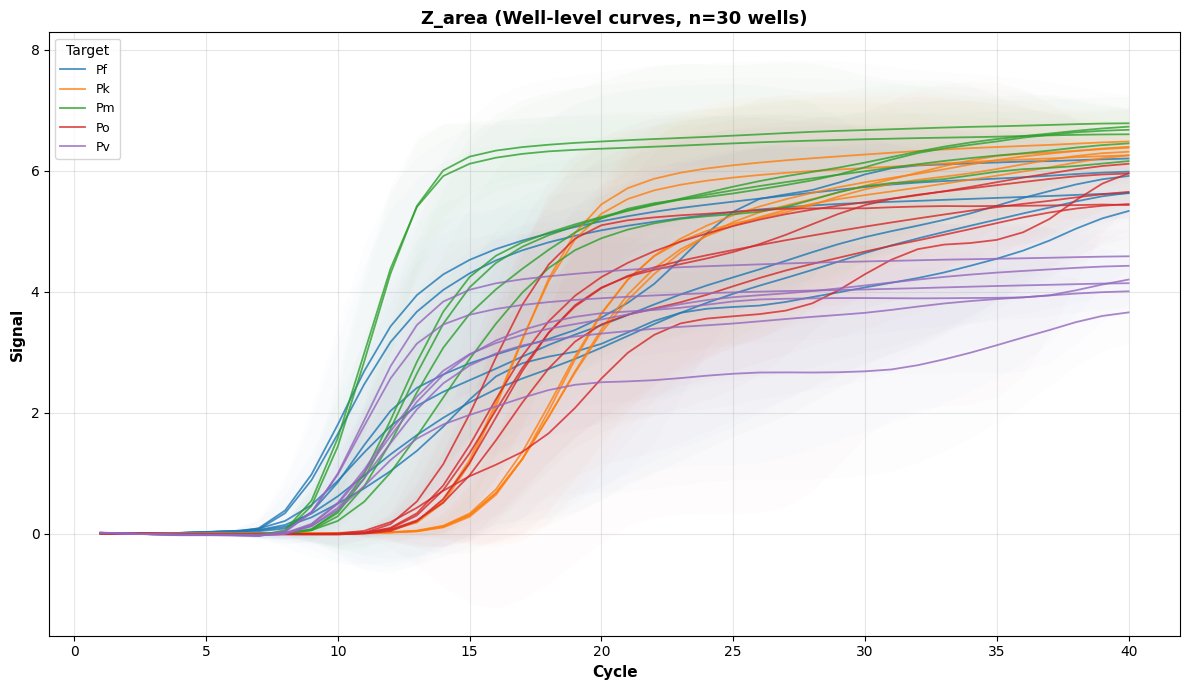

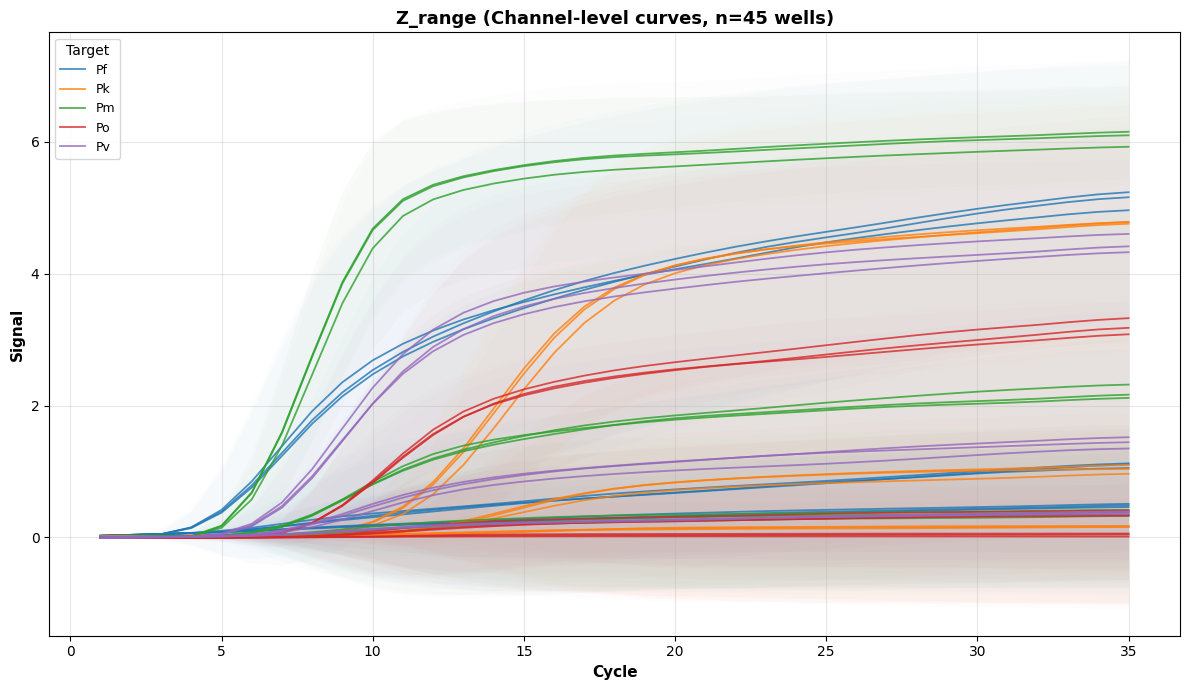

In [60]:
plot_raw_curves_by_well(config.LAB_EXP_FOLDER, folder_index=3)
plot_raw_curves_by_well(config.LAB_EXP_FOLDER, folder_index=4)

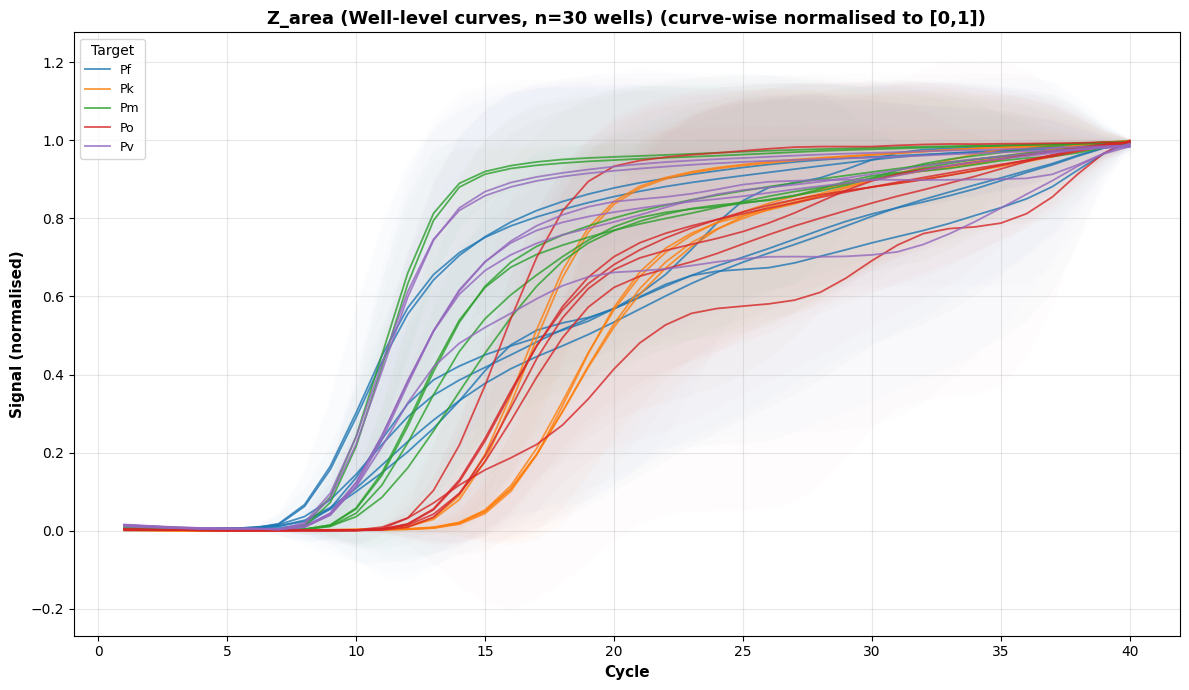

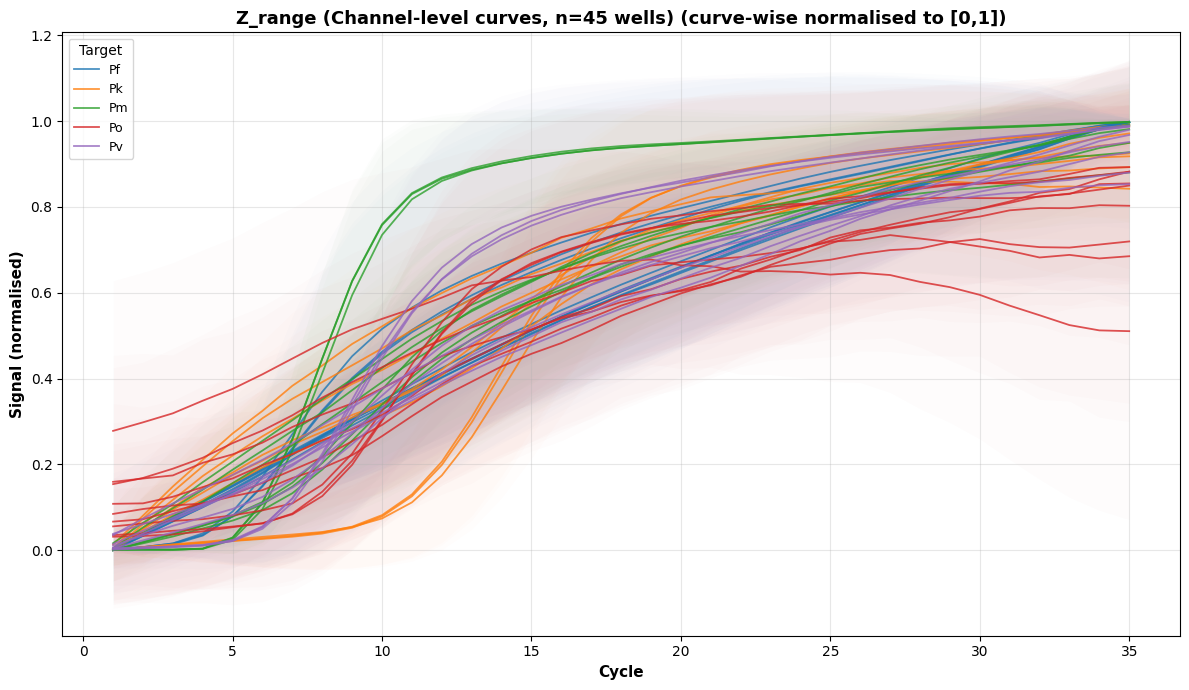

In [61]:
plot_raw_curves_by_well(config.LAB_EXP_FOLDER, folder_index=3, normalize=True)
plot_raw_curves_by_well(config.LAB_EXP_FOLDER, folder_index=4, normalize=True)

In [62]:
def plot_raw_curves_by_well_faceted(exp_folder, folder_index, normalize=False):
    """1 figure, 1 subplot per Target label, shared y-axis across subplots. Each subplot
    draws one line per well belonging to that label (mean across the well's dPCR partition
    rows), each well in its own distinct colour with a legend by well/channel number, plus
    a ±std shaded band (alpha=0.05). Reads area_strategy.csv/range_strategy.xlsx directly --
    well-identifier column is 'Well' on area_strategy, 'Channel' on range_strategy.
    If normalize=True, each raw curve (each row, independently) is min-max scaled to [0,1]
    before being averaged into its well's mean curve.
    """
    folder_names = sorted([
        name for name in os.listdir(exp_folder)
        if os.path.isdir(os.path.join(exp_folder, name)) and name not in config.EXCLUDED_FOLDERS
    ])
    if folder_index >= len(folder_names):
        raise IndexError(f"folder_index {folder_index} out of bounds for {len(folder_names)} folders: {folder_names}")
    folder_name = folder_names[folder_index]
    file_path = os.path.join(exp_folder, folder_name, lab01b.FILE_MAPPING[folder_name])
    df = lab01b._read_table(file_path)

    well_col = "Well" if "Well" in df.columns else "Channel"
    target_col = lab01b.FILE_TARGET[folder_name]

    cycle_cols = [col for col in df.columns
                  if str(col).startswith("Cycle") or re.match(r'^\d+(\.\d+)?$', str(col))]
    sorted_cycle_cols = sorted(cycle_cols, key=lab01b.get_numeric_sort_key)
    timestamps = np.array([lab01b.get_numeric_sort_key(c) for c in sorted_cycle_cols])

    curve_vals_all = df[sorted_cycle_cols].to_numpy().astype(np.float64)
    if normalize:
        row_min = curve_vals_all.min(axis=1, keepdims=True)
        row_max = curve_vals_all.max(axis=1, keepdims=True)
        denom = np.where(row_max - row_min == 0, 1, row_max - row_min)
        curve_vals_all = (curve_vals_all - row_min) / denom
    norm_df = pd.DataFrame(curve_vals_all, columns=sorted_cycle_cols, index=df.index)
    df = pd.concat([df[[well_col, target_col]], norm_df], axis=1)

    targets = sorted(df[target_col].unique())
    n = len(targets)
    ncols = min(5, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5 * ncols, 4.8 * nrows), squeeze=False, sharey=True)
    axes_flat = axes.flatten()

    for i, target in enumerate(targets):
        ax = axes_flat[i]
        sub_df = df[df[target_col] == target]
        well_ids = sorted(sub_df[well_col].unique())
        well_cmap = plt.get_cmap("tab20", len(well_ids))
        well_color_map = {w: well_cmap(j) for j, w in enumerate(well_ids)}

        for well_id in well_ids:
            well_df = sub_df[sub_df[well_col] == well_id]
            curve_vals = well_df[sorted_cycle_cols].to_numpy()
            mean_curve = curve_vals.mean(axis=0)
            std_curve = curve_vals.std(axis=0)
            color = well_color_map[well_id]
            ax.plot(timestamps, mean_curve, color=color, lw=1.3, alpha=0.9, label=f"{well_col} {well_id}")
            ax.fill_between(timestamps, mean_curve - std_curve, mean_curve + std_curve,
                             color=color, alpha=0.05, linewidth=0)

        ax.set_title(f"{target} (n={len(well_ids)} wells)", fontsize=11, fontweight="bold")
        ax.set_xlabel("Cycle", fontsize=9)
        ax.set_ylabel("Signal (normalised)" if normalize else "Signal", fontsize=9)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=6, ncol=2, loc="upper left", framealpha=0.6)

    for j in range(n, len(axes_flat)):
        axes_flat[j].axis("off")

    suffix = " (curve-wise normalised to [0,1])" if normalize else ""
    fig.suptitle(f"{folder_name}: Per-Well Curves (±std) Faceted by Target{suffix}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


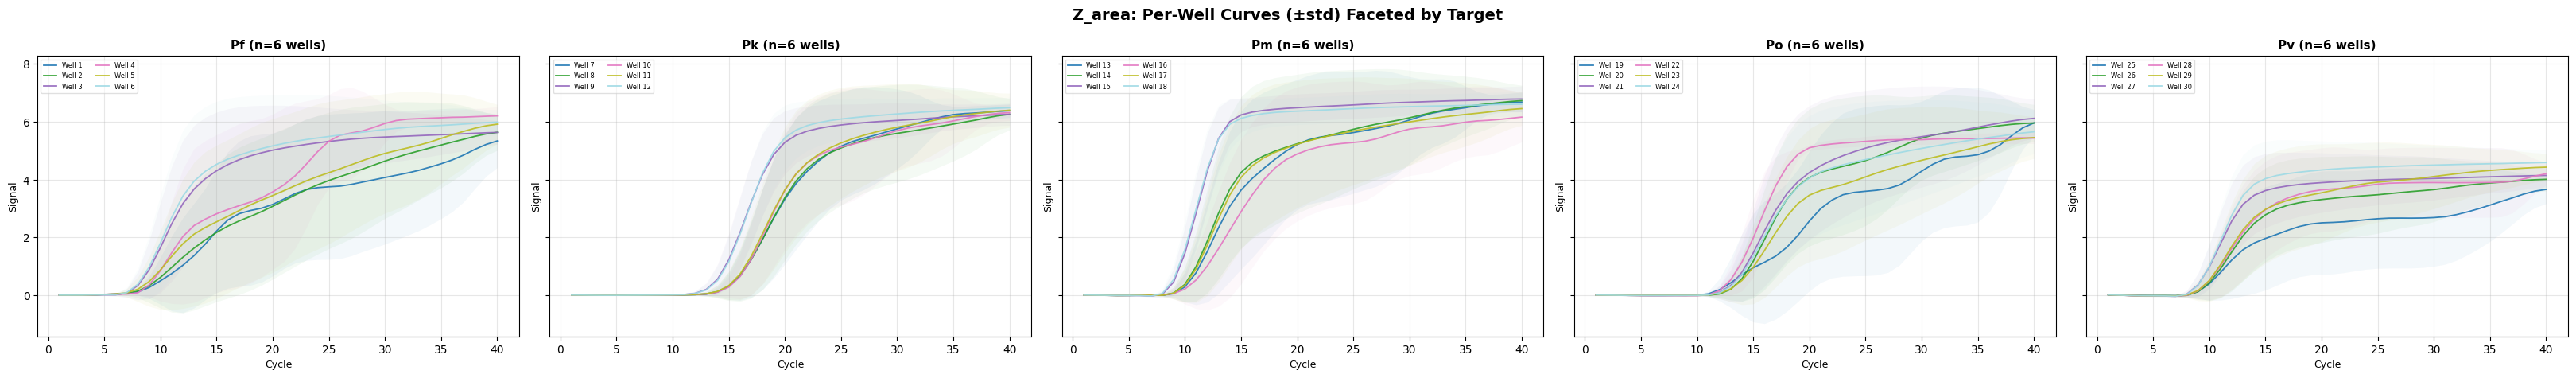

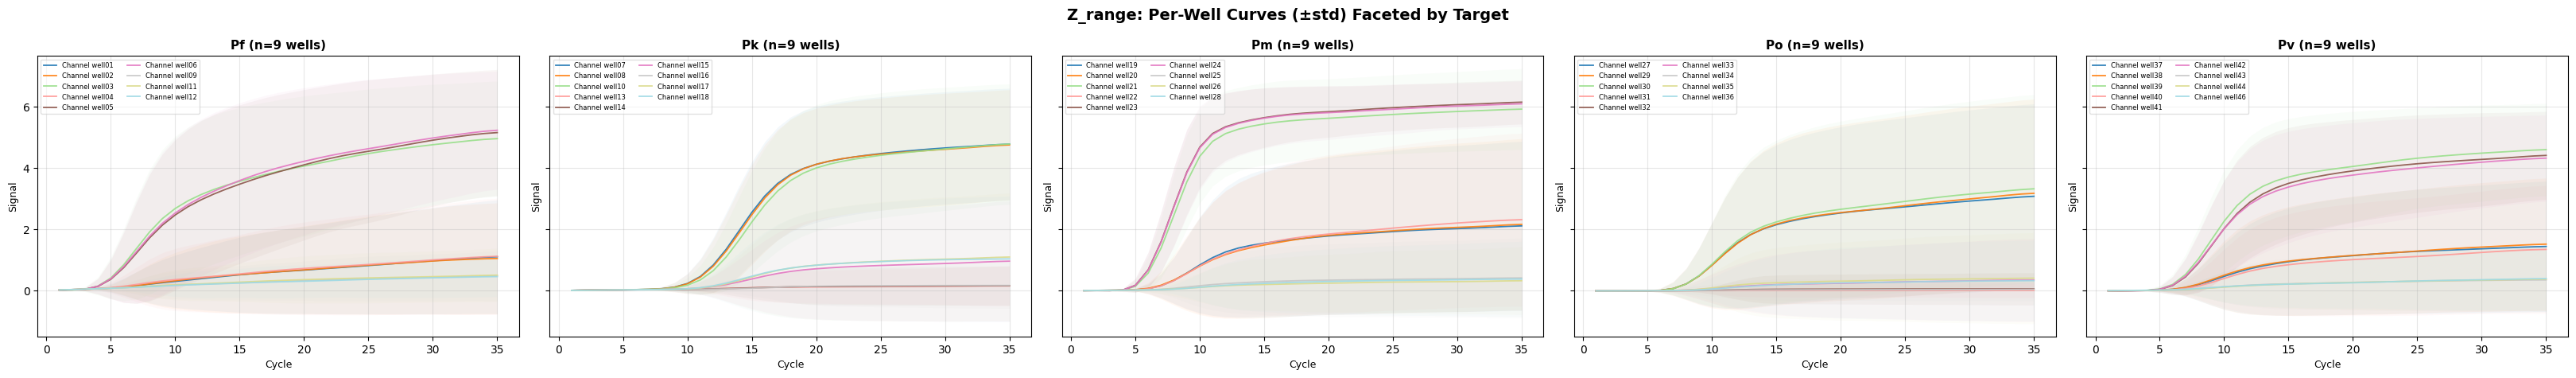

In [63]:
plot_raw_curves_by_well_faceted(config.LAB_EXP_FOLDER, folder_index=3)
plot_raw_curves_by_well_faceted(config.LAB_EXP_FOLDER, folder_index=4)

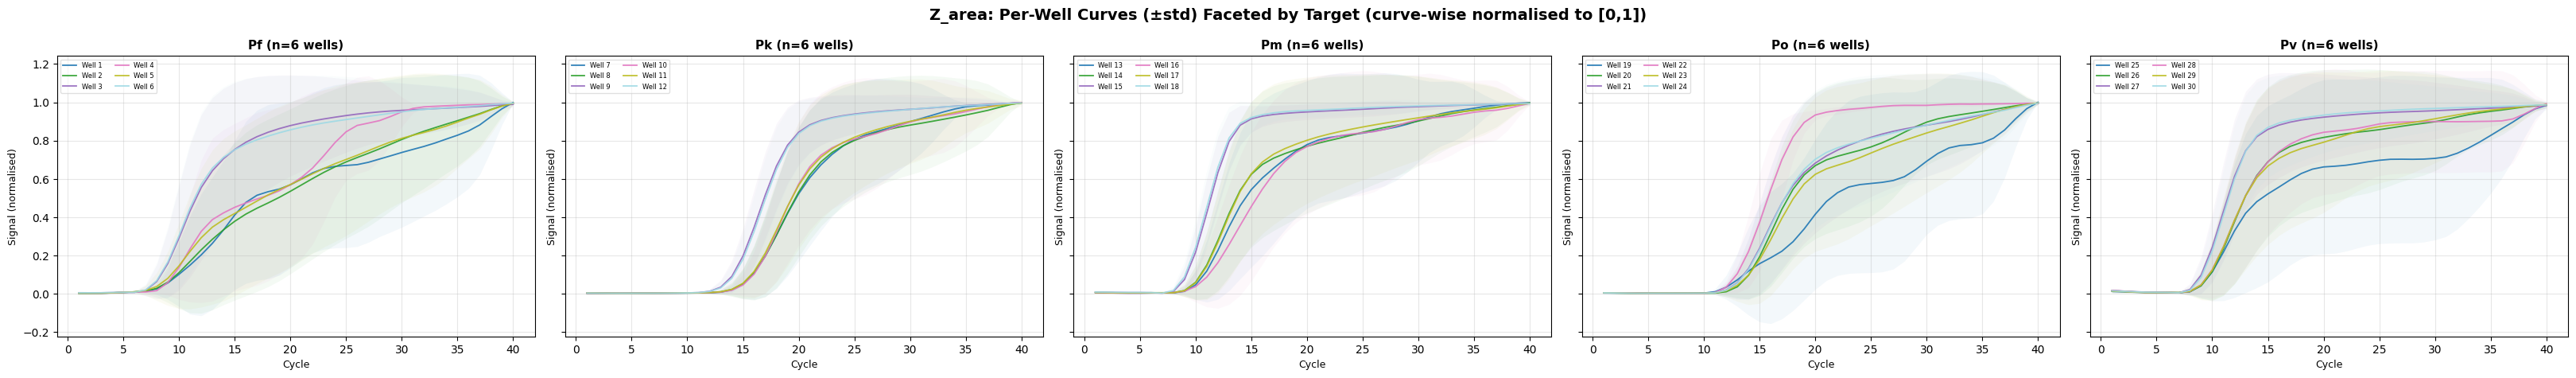

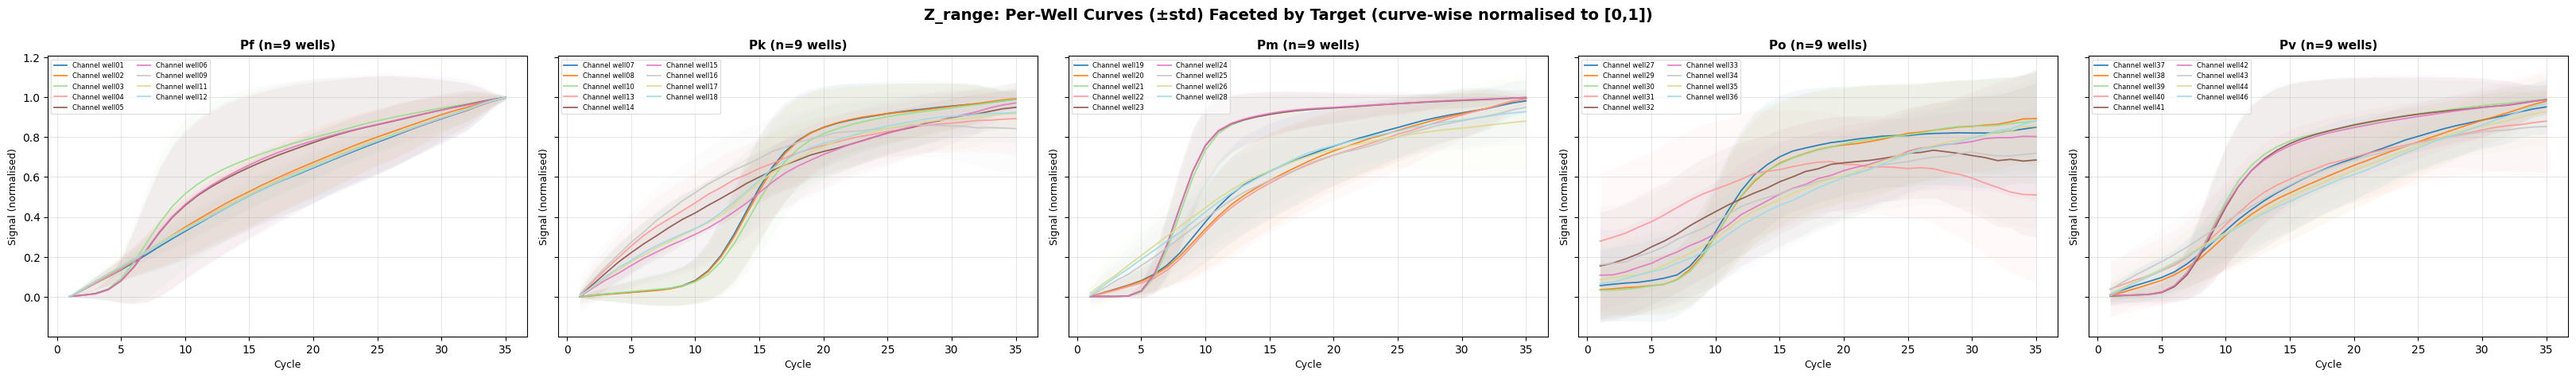

In [64]:
plot_raw_curves_by_well_faceted(config.LAB_EXP_FOLDER, folder_index=3, normalize=True)
plot_raw_curves_by_well_faceted(config.LAB_EXP_FOLDER, folder_index=4, normalize=True)

In [123]:
import os
import re
from itertools import combinations
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import importlib.util
import config

spec = importlib.util.spec_from_file_location(
    "lab01b", "/vol/bitbucket/gk225/POC_DDM/gk_code/main/01b_lab_curve_preprocessing.py"
)
lab01b = importlib.util.module_from_spec(spec)
spec.loader.exec_module(lab01b)


def per_fold_accuracies(res_entry, model_key):
    pred_key, _, _ = config.MODEL_KEY_MAP[model_key]
    if pred_key not in res_entry or not res_entry[pred_key]:
        return None
    y_trues, y_preds = res_entry["y_trues_"], res_entry[pred_key]
    return [float((np.asarray(yp) == np.asarray(yt)).mean()) for yt, yp in zip(y_trues, y_preds)]


def _strategy_for_folder(folder_name):
    """Maps a LAB_DDM_paper folder (e.g. 'Z_area') to its LAB_OneToOne strategy key
    (e.g. '1_area') via the shared source filename."""
    source_file = lab01b.FILE_MAPPING[folder_name]
    for strategy, fname in lab01b.FILE_MAPPING_ONE_TO_ONE.items():
        if fname == source_file:
            return strategy
    return None


def _pair_model_accuracy(strategy, label1, label2, model):
    combo_name = f"{strategy}__{label1}_vs_{label2}"
    results_path = Path(config.LAB_1TO1_EXP_FOLDER) / combo_name / config.TRAINING_10FOLD_RESULT_PATH
    if not results_path.exists():
        return None
    all_results = joblib.load(results_path)
    if "Ori Curves" not in all_results:
        return None
    res_entry = all_results["Ori Curves"].get("Native", {}).get(None)
    if res_entry is None:
        return None
    accs = per_fold_accuracies(res_entry, model)
    if accs is None:
        return None
    return float(np.mean(accs)) * 100, float(np.std(accs)) * 100


def plot_curves_by_pair(exp_folder, folder_index, average_by_well=False, model=None):
    """1 figure, 1 row per label pair. average_by_well controls whether to plot every
    individual curve or one averaged line per well. If model is given, looks up that
    pair's trained accuracy from LAB_OneToOne's one-to-one results and adds it to the title.
    """
    folder_names = sorted([
        name for name in os.listdir(exp_folder)
        if os.path.isdir(os.path.join(exp_folder, name)) and name not in config.EXCLUDED_FOLDERS
    ])
    if folder_index >= len(folder_names):
        raise IndexError(f"folder_index {folder_index} out of bounds for {len(folder_names)} folders: {folder_names}")
    folder_name = folder_names[folder_index]
    file_path = os.path.join(exp_folder, folder_name, lab01b.FILE_MAPPING[folder_name])
    df = lab01b._read_table(file_path)

    well_col = "Well" if "Well" in df.columns else "Channel"
    target_col = lab01b.FILE_TARGET[folder_name]

    cycle_cols = [col for col in df.columns
                  if str(col).startswith("Cycle") or re.match(r'^\d+(\.\d+)?$', str(col))]
    sorted_cycle_cols = sorted(cycle_cols, key=lab01b.get_numeric_sort_key)
    timestamps = np.array([lab01b.get_numeric_sort_key(c) for c in sorted_cycle_cols])

    targets = sorted(df[target_col].unique())
    pairs = list(combinations(targets, 2))
    cmap = plt.get_cmap("tab10")
    color_map = {t: cmap(i % 10) for i, t in enumerate(targets)}

    strategy = _strategy_for_folder(folder_name) if model else None
    if model and strategy is None:
        print(f"[WARN] no one-to-one strategy found for folder '{folder_name}' -- accuracy will be omitted.")

    fig, axes = plt.subplots(len(pairs), 1, figsize=(10, 3.2 * len(pairs)), sharex=True)
    if len(pairs) == 1:
        axes = [axes]

    for ax, (label1, label2) in zip(axes, pairs):
        sub_df = df[df[target_col].isin([label1, label2])]
        for target in (label1, label2):
            target_df = sub_df[sub_df[target_col] == target]
            color = color_map[target]
            if average_by_well:
                for well_id, well_df in target_df.groupby(well_col):
                    curve = well_df[sorted_cycle_cols].mean(axis=0).to_numpy()
                    ax.plot(timestamps, curve, color=color, lw=1.2, alpha=0.8)
            else:
                for curve in target_df[sorted_cycle_cols].to_numpy():
                    ax.plot(timestamps, curve, color=color, lw=0.8, alpha=0.4)
            ax.plot([], [], color=color, lw=2, label=str(target))

        title = f"{label1} vs {label2}"
        if model and strategy:
            result = _pair_model_accuracy(strategy, label1, label2, model)
            if result is not None:
                acc, std = result
                model_label = config.MODEL_PRINT_MAP.get(model, model)
                title += f"  |  {model_label}: {acc:.1f}±{std:.1f}%"
            else:
                title += f"  |  {model}: n/a"
        ax.set_title(title, fontsize=10, fontweight="bold")
        ax.set_ylabel("Signal", fontsize=9)
        ax.legend(fontsize=8, loc="upper left")
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel("Cycle", fontsize=10, fontweight="bold")
    mode_label = "averaged by well" if average_by_well else "all curves"
    fig.suptitle(f"{folder_name}: Per-Pair Curves ({mode_label})", fontsize=13, fontweight="bold", y=1.0)
    plt.tight_layout()
    plt.show()


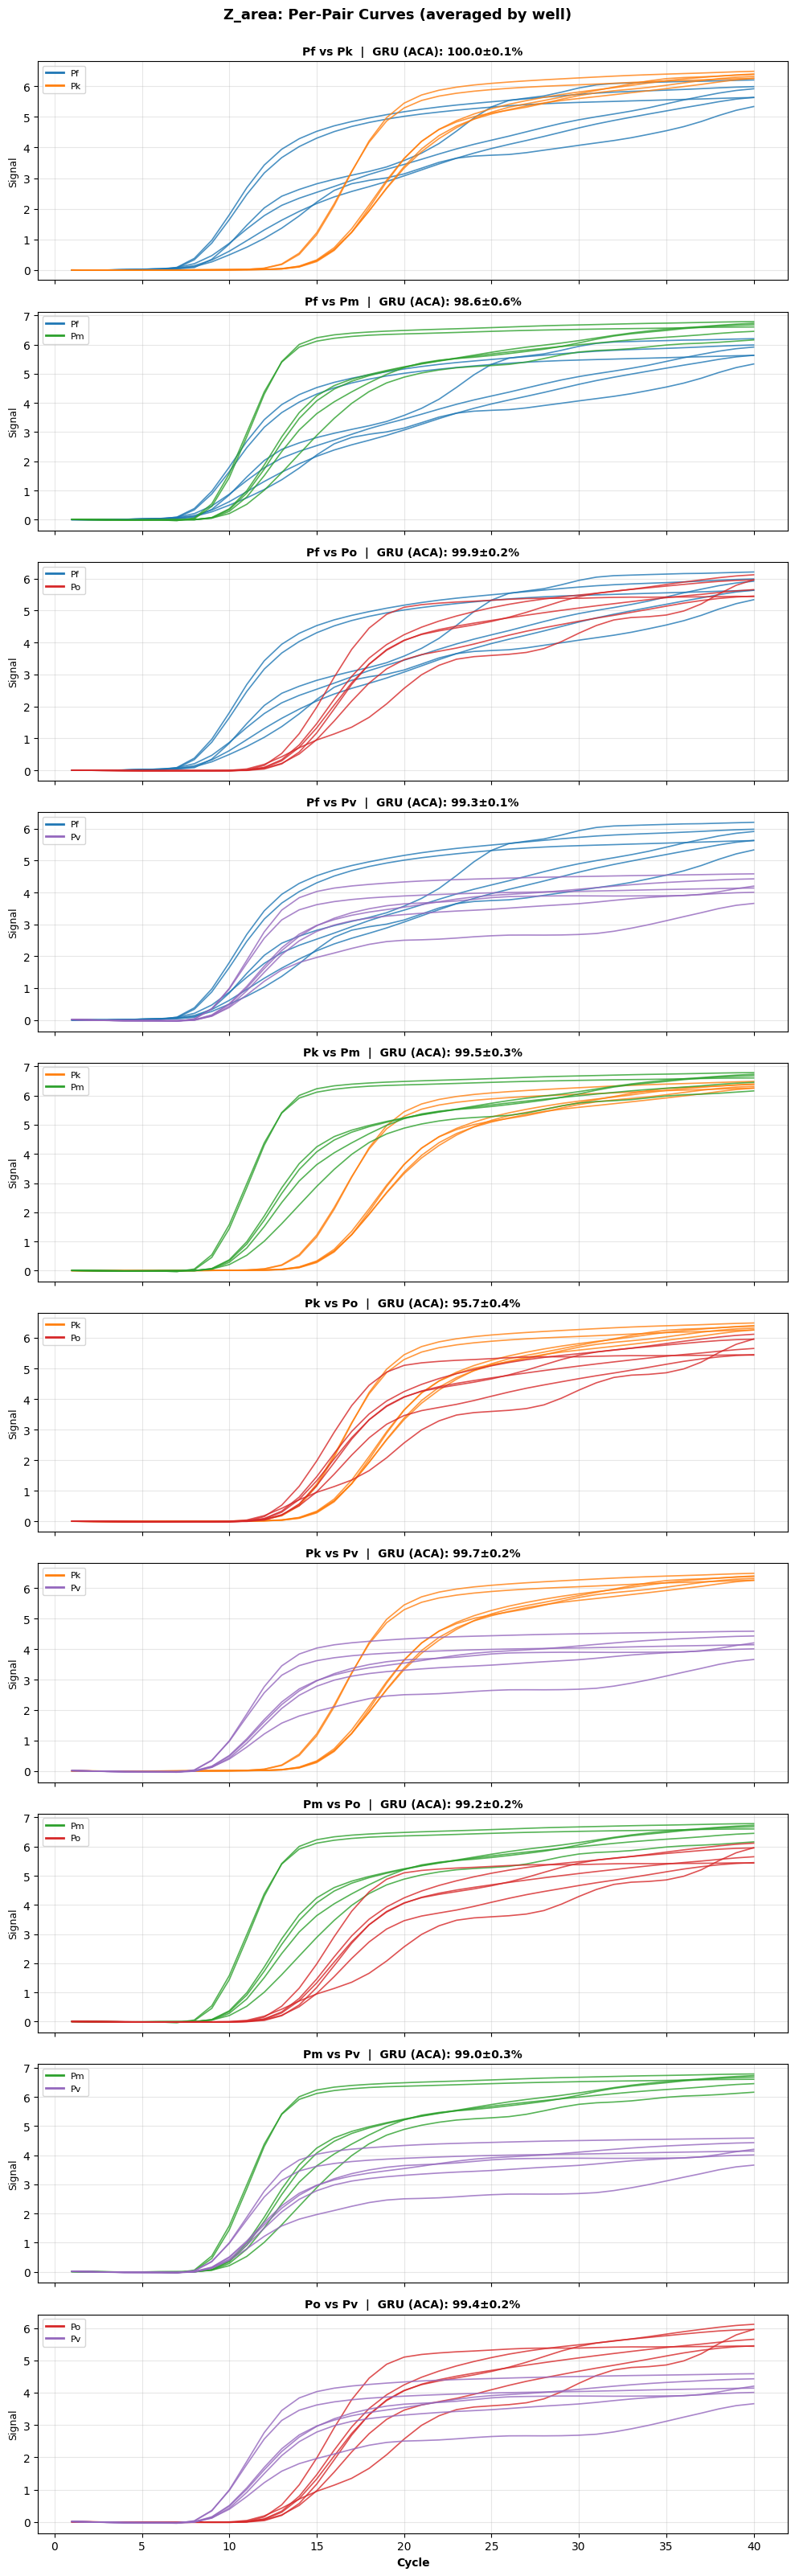

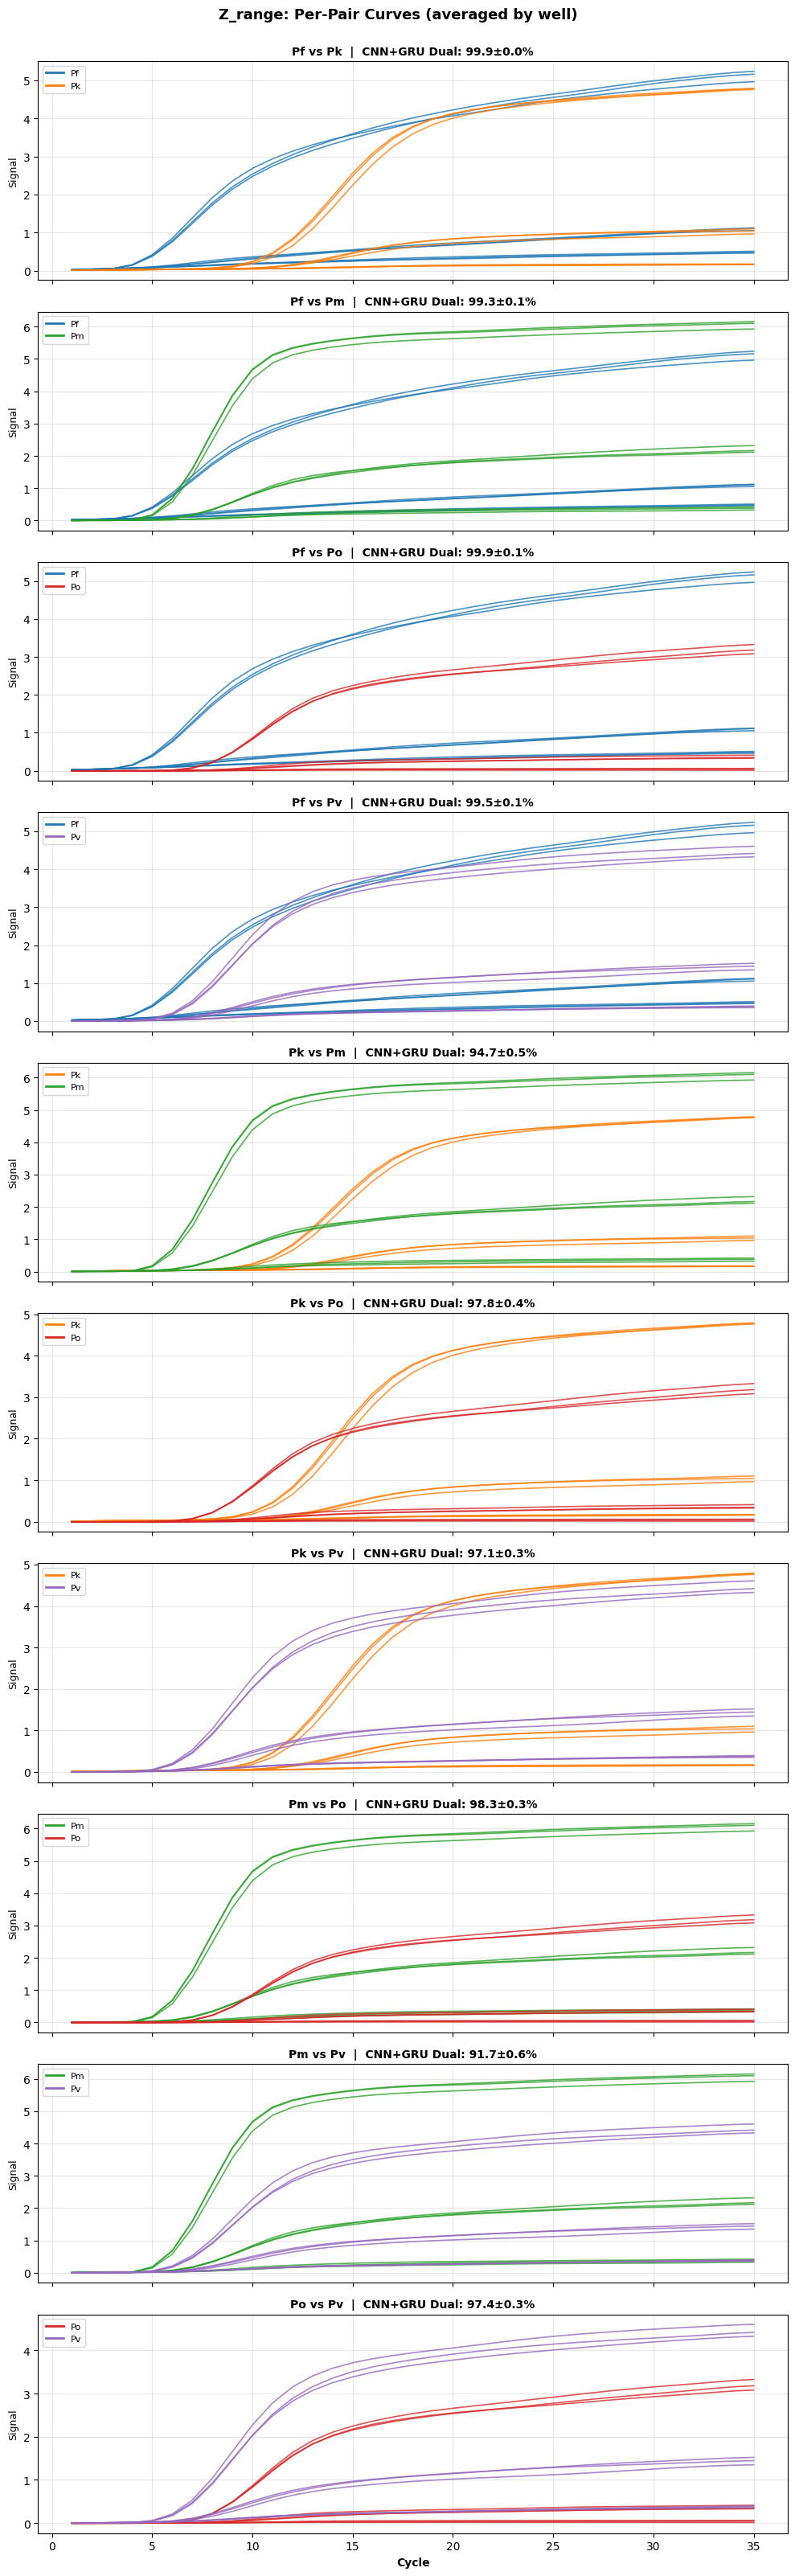

In [124]:
# plot_curves_by_pair(config.LAB_EXP_FOLDER, 3, average_by_well=False)
plot_curves_by_pair(config.LAB_EXP_FOLDER, 3, average_by_well=True, model="gru")

# plot_curves_by_pair(config.LAB_EXP_FOLDER, 4, average_by_well=False)
plot_curves_by_pair(config.LAB_EXP_FOLDER, 4, average_by_well=True, model="cnn_gru_dual")


In [133]:
import os
from pathlib import Path
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import importlib.util
import config
%matplotlib inline

def _load_digit_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

lab01b = _load_digit_module("lab01b", "01b_lab_curve_preprocessing.py")
report06 = _load_digit_module("report06", "06_model_prediction_report.py")  # reuses compute_filtered_splits


def plot_correct_wrong_by_well(model, pair, curve_type="ori_curve", n_splits=5):
    """Adapts 06_model_prediction_report.py's correct/wrong curve tab, but rows are the
    actual physical well/channel (not target) -- 2 columns: correct (green) / wrong (red).
    One figure per strategy that has this pair (1_area, 2_range)."""
    label1, label2 = pair.split("_vs_")

    for strategy in sorted(lab01b.FILE_MAPPING_ONE_TO_ONE.keys()):
        combo_name = f"{strategy}__{pair}"
        combo_path = Path(config.LAB_1TO1_EXP_FOLDER) / combo_name
        state_path = combo_path / config.TRAINING_DATA_PATH
        results_path = combo_path / config.TRAINING_10FOLD_RESULT_PATH
        if not state_path.exists() or not results_path.exists():
            print(f"[SKIP] {combo_name}: missing results")
            continue

        state = joblib.load(state_path)
        dataset_name = list(state["dataset_name"])
        dataset = state["dataset"]
        Y_well_raw = np.asarray(state["Y_well"])  # = target labels for this combo

        try:
            curve_idx, resolved_name = config.resolve_curve_dataset_idx(curve_type, dataset_name)
        except ValueError as e:
            print(f"[SKIP] {combo_name}: {e}")
            continue
        curves = dataset[curve_idx]

        encoder = LabelEncoder()
        y_full = encoder.fit_transform(Y_well_raw)
        clean_title = resolved_name.replace("_", " ").title()

        all_ml_results = joblib.load(results_path)
        if clean_title not in all_ml_results or "Native" not in all_ml_results[clean_title]:
            print(f"[SKIP] {combo_name}: no Native results for {clean_title}")
            continue
        res_entry = all_ml_results[clean_title]["Native"].get(None)
        if res_entry is None:
            print(f"[SKIP] {combo_name}: no baseline (None) filter results")
            continue

        pred_key, _, _ = config.MODEL_KEY_MAP[model]
        if pred_key not in res_entry:
            print(f"[SKIP] {combo_name}: no '{model}' results")
            continue

        # re-derive the same CV splits/global indices evaluate_outlier_filters used
        split_info = report06.compute_filtered_splits(y_full, None, None, n_splits)
        if split_info is None:
            print(f"[SKIP] {combo_name}: could not reconstruct splits")
            continue
        global_idx, y_masked, splits = split_info

        y_trues_list = res_entry["y_trues_"]
        preds_list = res_entry[pred_key]

        correct_idx_list, wrong_idx_list = [], []
        mismatch = False
        for fold_i, (_, test_idx_local) in enumerate(splits):
            if fold_i >= len(preds_list) or fold_i >= len(y_trues_list):
                break
            y_true_fold = y_masked[test_idx_local]
            y_pred_fold = np.asarray(preds_list[fold_i])
            y_true_cached = np.asarray(y_trues_list[fold_i])
            if y_true_fold.shape != y_true_cached.shape or not np.array_equal(y_true_fold, y_true_cached):
                mismatch = True
                break
            gidx = global_idx[test_idx_local]
            mask_ok = y_true_fold == y_pred_fold
            correct_idx_list.append(gidx[mask_ok])
            wrong_idx_list.append(gidx[~mask_ok])
        if mismatch or not correct_idx_list:
            print(f"[SKIP] {combo_name}: split mismatch (try a different n_splits)")
            continue
        correct_idx = np.concatenate(correct_idx_list)
        wrong_idx = np.concatenate(wrong_idx_list)

        # well/channel IDs aren't stored in the combo's joblib -- reconstruct from the
        # raw file using the same mask order load_lab_curves_one_to_one used
        source_file = lab01b.FILE_MAPPING_ONE_TO_ONE[strategy]
        df_raw = lab01b._read_table(Path(config.LAB_1TO1_EXP_FOLDER) / strategy / source_file)
        well_col = "Well" if "Well" in df_raw.columns else "Channel"
        target_col = lab01b.FILE_TARGET_ONE_TO_ONE[strategy]
        mask_pair = df_raw[target_col].isin([label1, label2]).to_numpy()
        well_ids = df_raw[well_col].to_numpy()[mask_pair]
        target_check = df_raw[target_col].to_numpy()[mask_pair]
        if not np.array_equal(target_check, Y_well_raw):
            print(f"[WARN] {combo_name}: well-id reconstruction order mismatch, skipping")
            continue

        unique_wells = np.unique(well_ids)
        n_wells = len(unique_wells)
        fig, axes = plt.subplots(n_wells, 2, figsize=(8, 2.2 * n_wells), squeeze=False, sharey="row")
        correct_wells = well_ids[correct_idx]
        wrong_wells = well_ids[wrong_idx]
        for i, well in enumerate(unique_wells):
            well_target = Y_well_raw[well_ids == well][0]
            well_title = f"{well_col} {well} ({well_target})"
            wc = correct_idx[correct_wells == well]
            ww = wrong_idx[wrong_wells == well]
            ax_ok, ax_bad = axes[i, 0], axes[i, 1]
            if len(wc) > 0:
                ax_ok.plot(curves[wc].T, color="#27ae60", alpha=0.3, linewidth=0.8)
            ax_ok.set_title(f"{well_title} - Correct (n={len(wc)})", fontsize=9, fontweight="bold")
            if len(ww) > 0:
                ax_bad.plot(curves[ww].T, color="#e74c3c", alpha=0.4, linewidth=0.8)
            ax_bad.set_title(f"{well_title} - Wrong (n={len(ww)})", fontsize=9, fontweight="bold")
            for ax in (ax_ok, ax_bad):
                ax.set_xlabel("Time index", fontsize=8)
                ax.set_ylabel("Signal", fontsize=8)
                ax.grid(alpha=0.3)
        model_label = config.MODEL_PRINT_MAP.get(model, model)
        fig.suptitle(f"{combo_name} | {model_label}: Correct vs Wrong by Well", fontweight="bold", y=1.0)
        plt.tight_layout()
        plt.show()


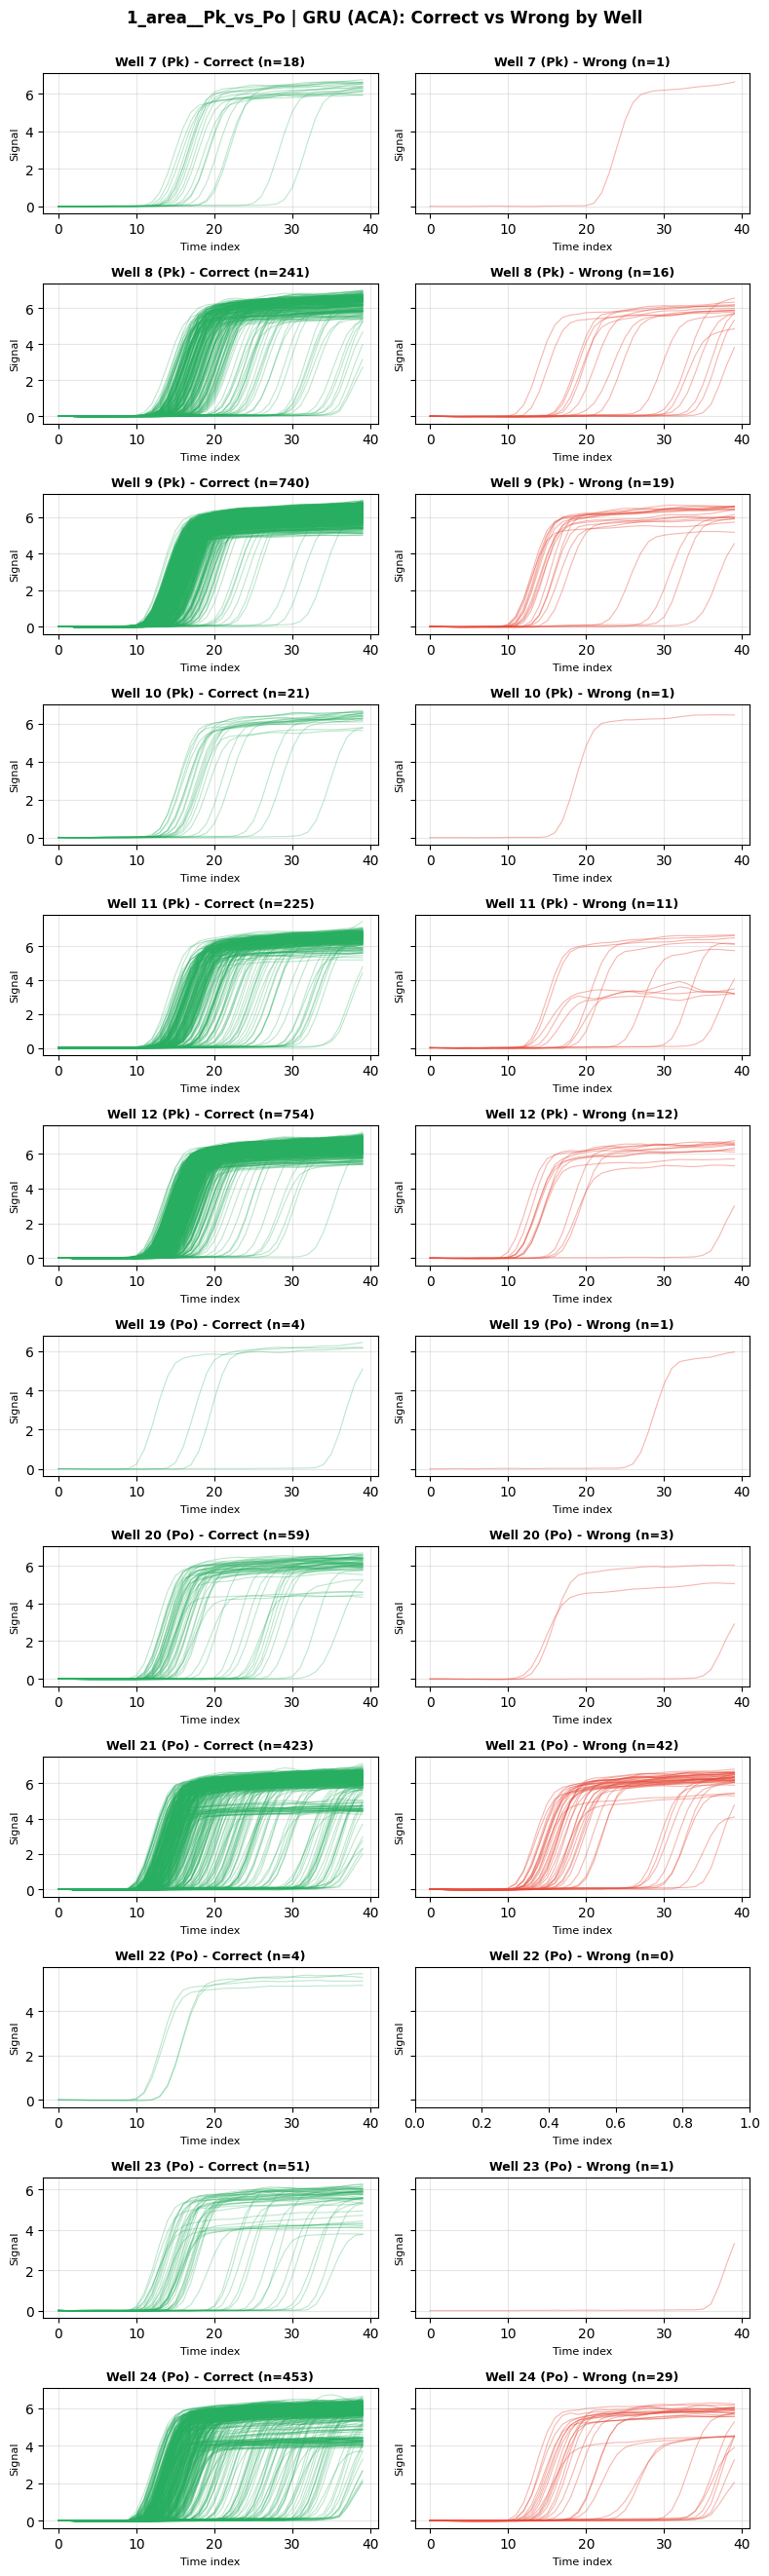

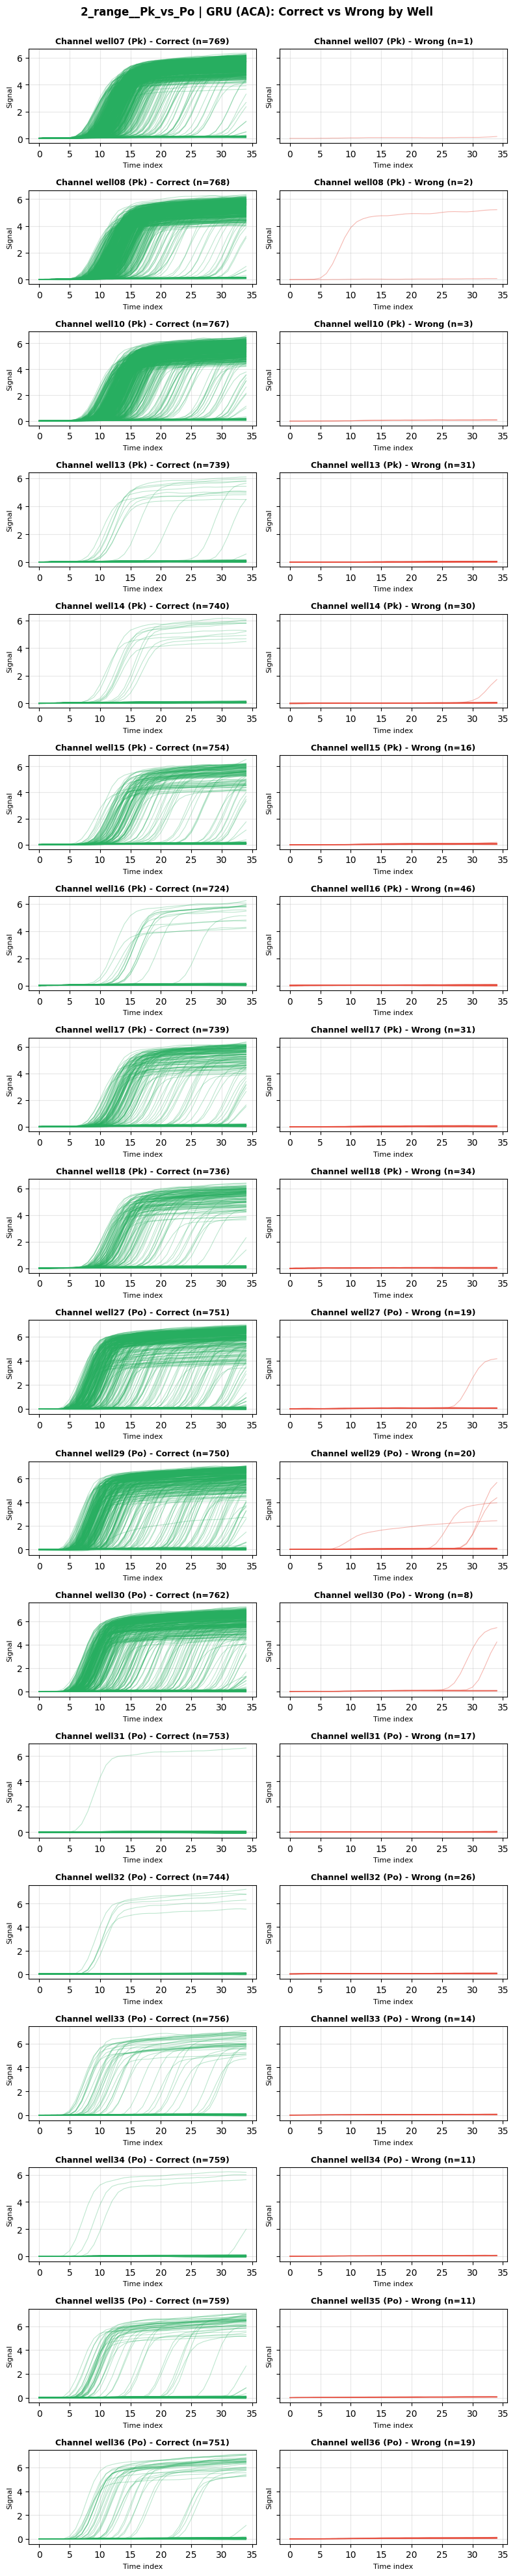

In [137]:
%matplotlib inline
plot_correct_wrong_by_well("gru", "Pk_vs_Po")